# Comparison of individual parcellations using task vs. resting prior

This jupyter notebook is to demenstrate a comparison between different individual parcellations generated from group priors of different modalities.

In [1]:
import time
import numpy as np
import torch as pt
import nibabel as nb
import nitools as nt
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import Functional_Fusion.atlas_map as am
import Functional_Fusion.dataset as ds
import HierarchBayesParcel.arrangements as ar
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.full_model as fm
import FusionModel.util as futil
import FusionModel.evaluate as ev

In [2]:
import os, sys, warnings
sys.path.append(os.path.abspath('..'))
warnings.filterwarnings('ignore')

# from global_config import MODEL_DIR, BASE_DIR, ATLAS_DIR, DEVICE
# from scripts.group_parcellation import build_ukb_datasets, convert_hard_to_prob, get_indiv_parcellation_from_model
# from scripts.indiv_eval import *

# Individual parcellation generation

## Group priors: Pure resting-state vs. task-based fusion

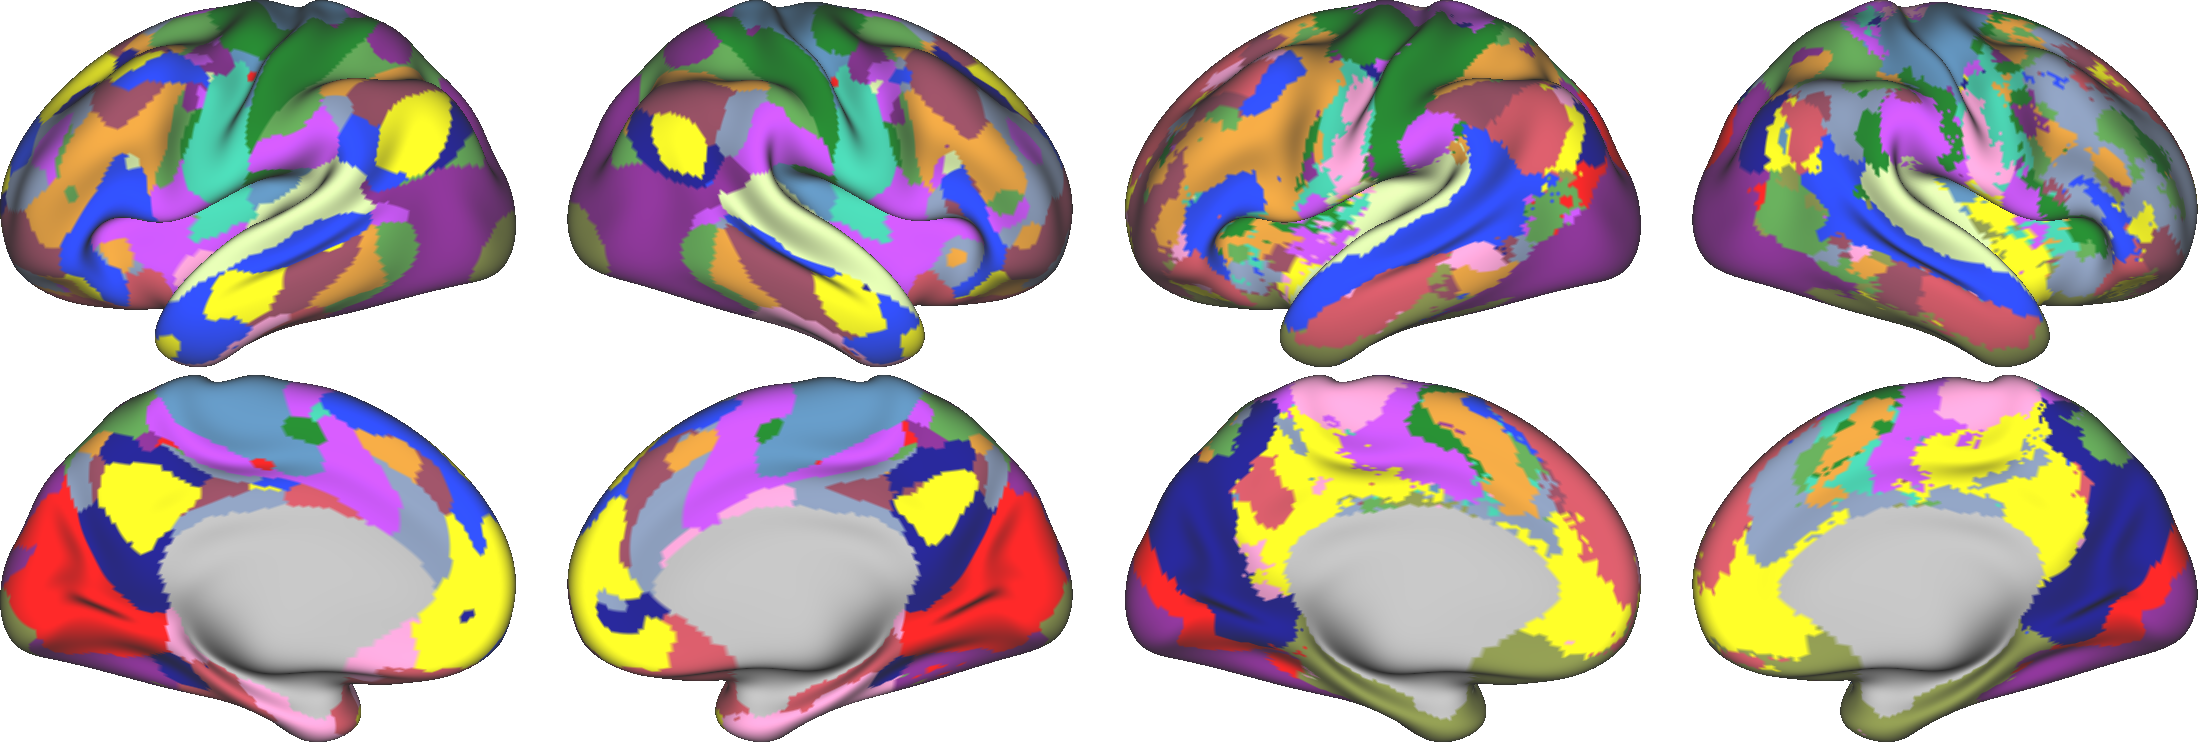

In [6]:
from IPython.display import Image, display, HTML

# Display the image with a caption
display(Image(filename='/PHShome/dz010/Documents/group_resting_vs_task.png'))
display(HTML("<p style='text-align:center;'> HBP resting-state (HCP 800 subjects) ------------------ HBP task-based fusion (6 datasets 87 subjects) </p>"))

## Option 1: Precision mapping using MDTB task individual data 

## (a) with resting prior

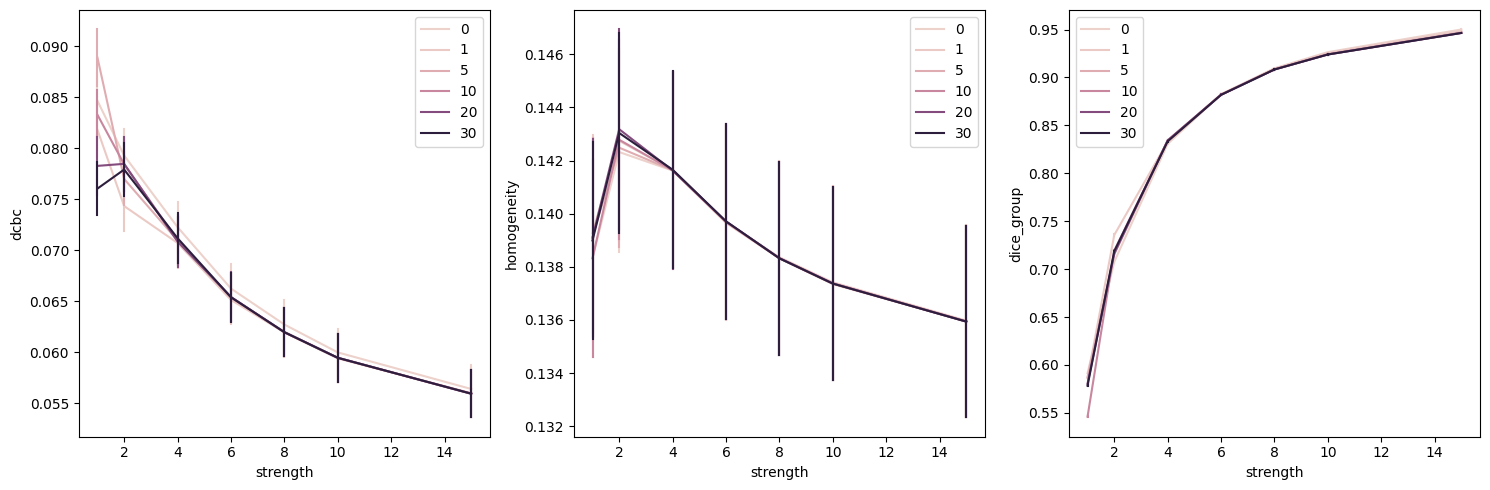

In [7]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP800+Md-ses1_indiv_test_on_Md-ses2.tsv', sep='\t')

# results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP40-ROI1483_on_HCP40validation_groupstrength-1to120_spatialW-0to120.tsv', sep='\t')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se",
            err_style="bars", markers=True, markersize=10)

plt.ylabel('dcbc')
plt.legend()

plt.subplot(1,3,2)
sb.lineplot(data=results, x="strength", y='homo_indiv', hue='spatial_w', errorbar="se",
            err_style="bars", markers=True, markersize=10)

plt.ylabel('homogeneity')
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se",
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

## (b) with task prior

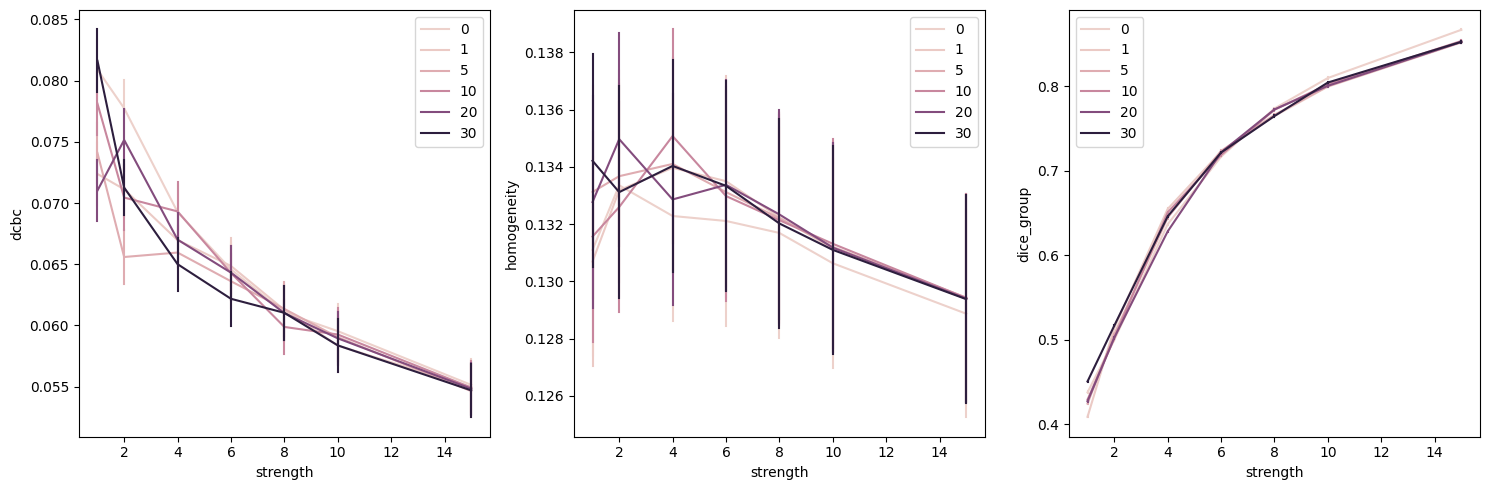

In [17]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_6taskfusion+Md-ses1_indiv_test_on_Md-ses2.tsv', sep='\t')

# results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP40-ROI1483_on_HCP40validation_groupstrength-1to120_spatialW-0to120.tsv', sep='\t')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se",
            err_style="bars", markers=True, markersize=10)

plt.ylabel('dcbc')
plt.legend()

plt.subplot(1,3,2)
sb.lineplot(data=results, x="strength", y='inhomo_indiv', hue='spatial_w', errorbar="se",
            err_style="bars", markers=True, markersize=10)

plt.ylabel('homogeneity')
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se",
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

## (c) Comparing

['CPRO' 'prediction' 'verbGeneration' 'spatialNavigation' 'spatialMap'
 'natureMovie' 'romanceMovie' 'landscapeMovie' 'motorSequence'
 'mentalRotation' 'nBackPic' 'emotionProcess' 'respAlt' 'visualSearch'
 'ToM' 'actionObservation' 'rest' 'all']


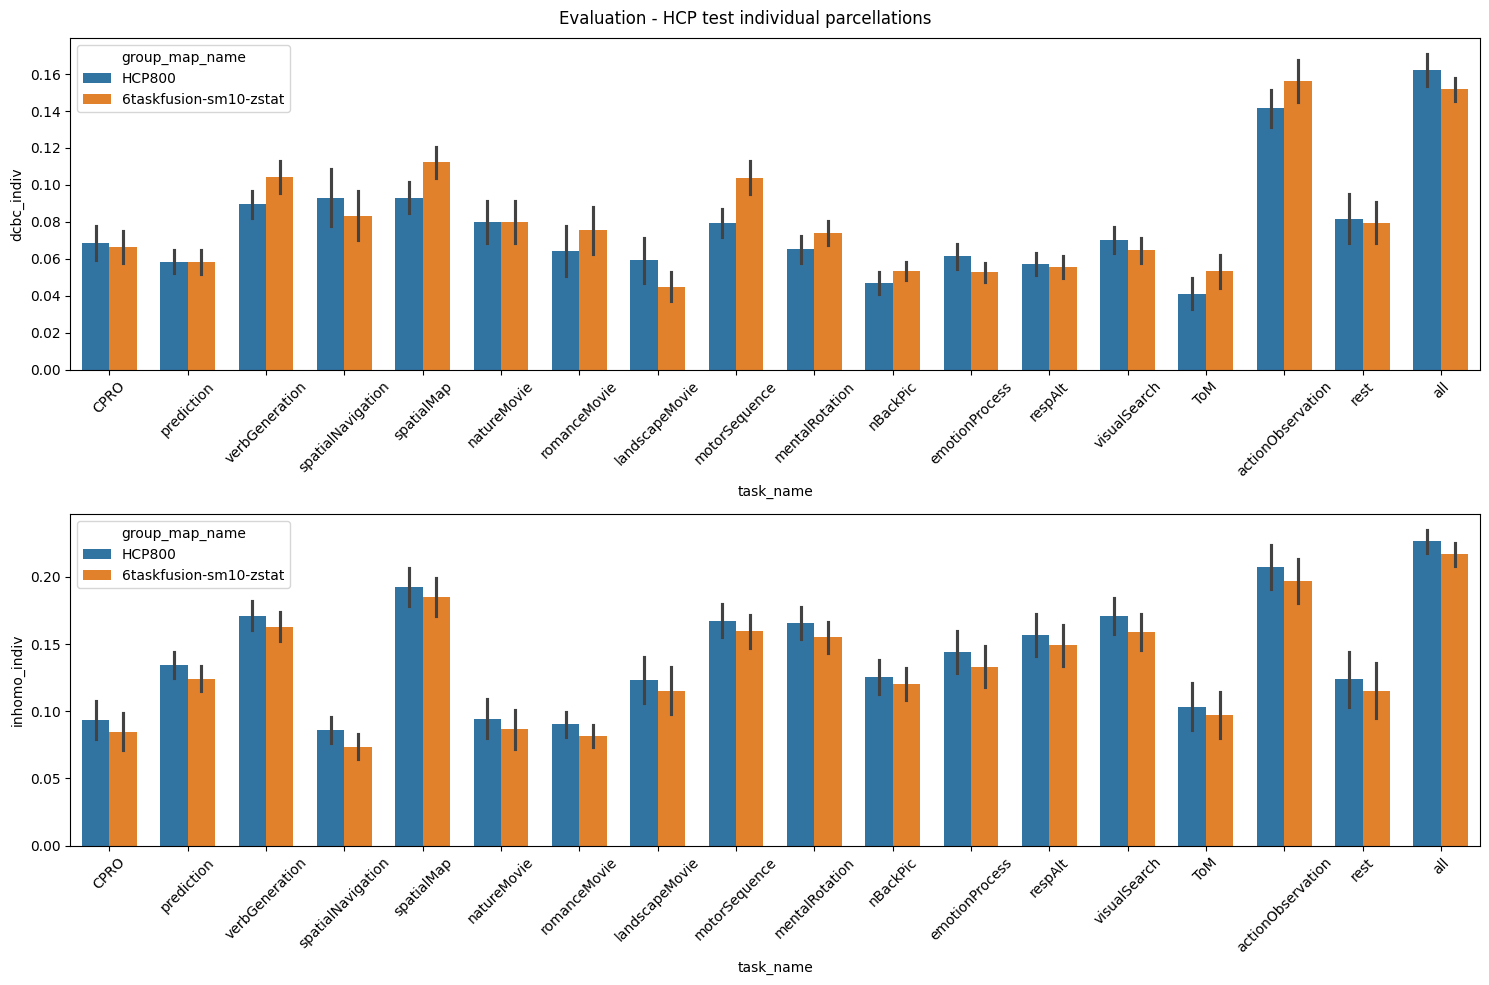

In [5]:
RES_DIR = '/data/tge/dzhi/Indiv_par/Evaluations'
results1 = pd.read_csv(RES_DIR + f'/eval_HCP800+Md-ses1_indiv_test_on_Md-ses2.tsv', sep='\t')
results1 = results1.loc[(results1['strength'] == 2) & (results1['spatial_w'] == 20)]

# results = results.replace(results.task_name.unique(), ['Executive', 'Social', 'Motor', 'Emotion', 'Numerical', 'Perception',
#                                           'Emotion', 'Temporal', 'Motor', 'Motor', 'Executive', 'Executive', 'Spatial',
#                                           'Executive', 'Language', 'Perception', 'Rest', 'Executive', 'Executive',
#                                           'Spatial', 'Social', 'Social', 'Perception', 'Spatial', 'Emotion', 'Motor'])

results2 = pd.read_csv(RES_DIR + f'/eval_6taskfusion+Md-ses1_indiv_test_on_Md-ses2.tsv', sep='\t')
results2 = results2.loc[(results2['strength'] == 1) & (results2['spatial_w'] == 30)]

results = pd.concat([results1, results2], ignore_index=True)
print(results.task_name.unique())

# Plot results
plt.figure(figsize=(15, 10))
plt.subplot(2,1,1)
# sb.boxplot(data=results, x='network', y='dice', hue='type', width=0.7)
sb.barplot(data=results, x='task_name', y='dcbc_indiv', hue='group_map_name', 
           errorbar='se', width=0.7)
plt.xticks(rotation=45)

plt.subplot(2,1,2)
sb.barplot(data=results, x='task_name', y='inhomo_indiv', hue='group_map_name', 
           errorbar='se', width=0.7)
plt.xticks(rotation=45)

plt.suptitle('Evaluation - HCP test individual parcellations')
plt.tight_layout()
plt.show()

## Option 2: Precision mapping using HCP task individual data 

## (a) with resting prior

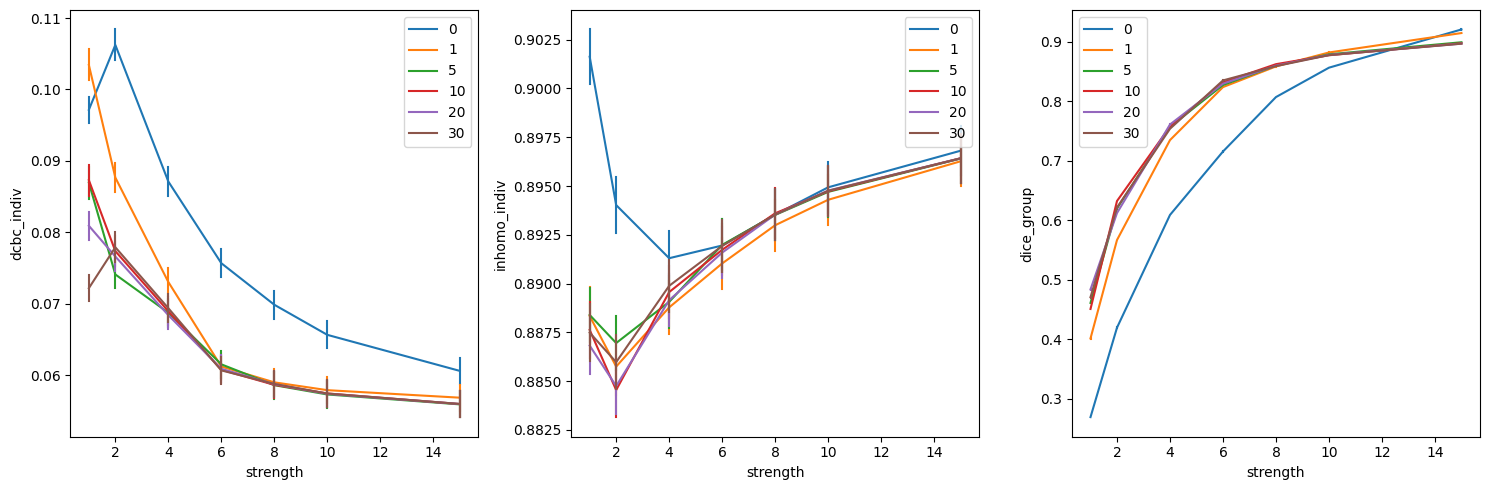

In [9]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_7taskfusion+HCPtask-half1_indiv-WcRBM_test_on_HCPtask-half2.tsv', sep='\t')

# results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP40-ROI1483_on_HCP40validation_groupstrength-1to120_spatialW-0to120.tsv', sep='\t')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,2)
sb.lineplot(data=results, x="strength", y='inhomo_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

## (b) with task prior

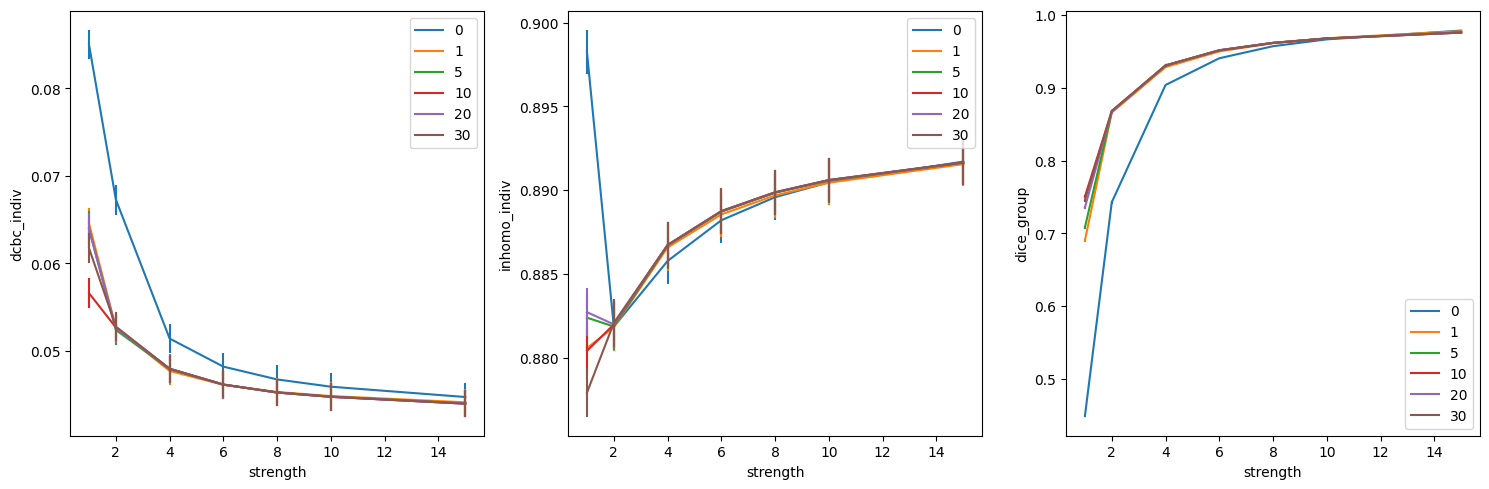

In [10]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP800+HCPtask-half1_indiv-WcRBM_test_on_HCPtask-half2.tsv', sep='\t')

# results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP40-ROI1483_on_HCP40validation_groupstrength-1to120_spatialW-0to120.tsv', sep='\t')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,2)
sb.lineplot(data=results, x="strength", y='inhomo_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

['EMOTION' 'GAMBLING' 'LANGUAGE' 'MOTOR' 'RELATIONAL' 'SOCIAL' 'WM' 'all']


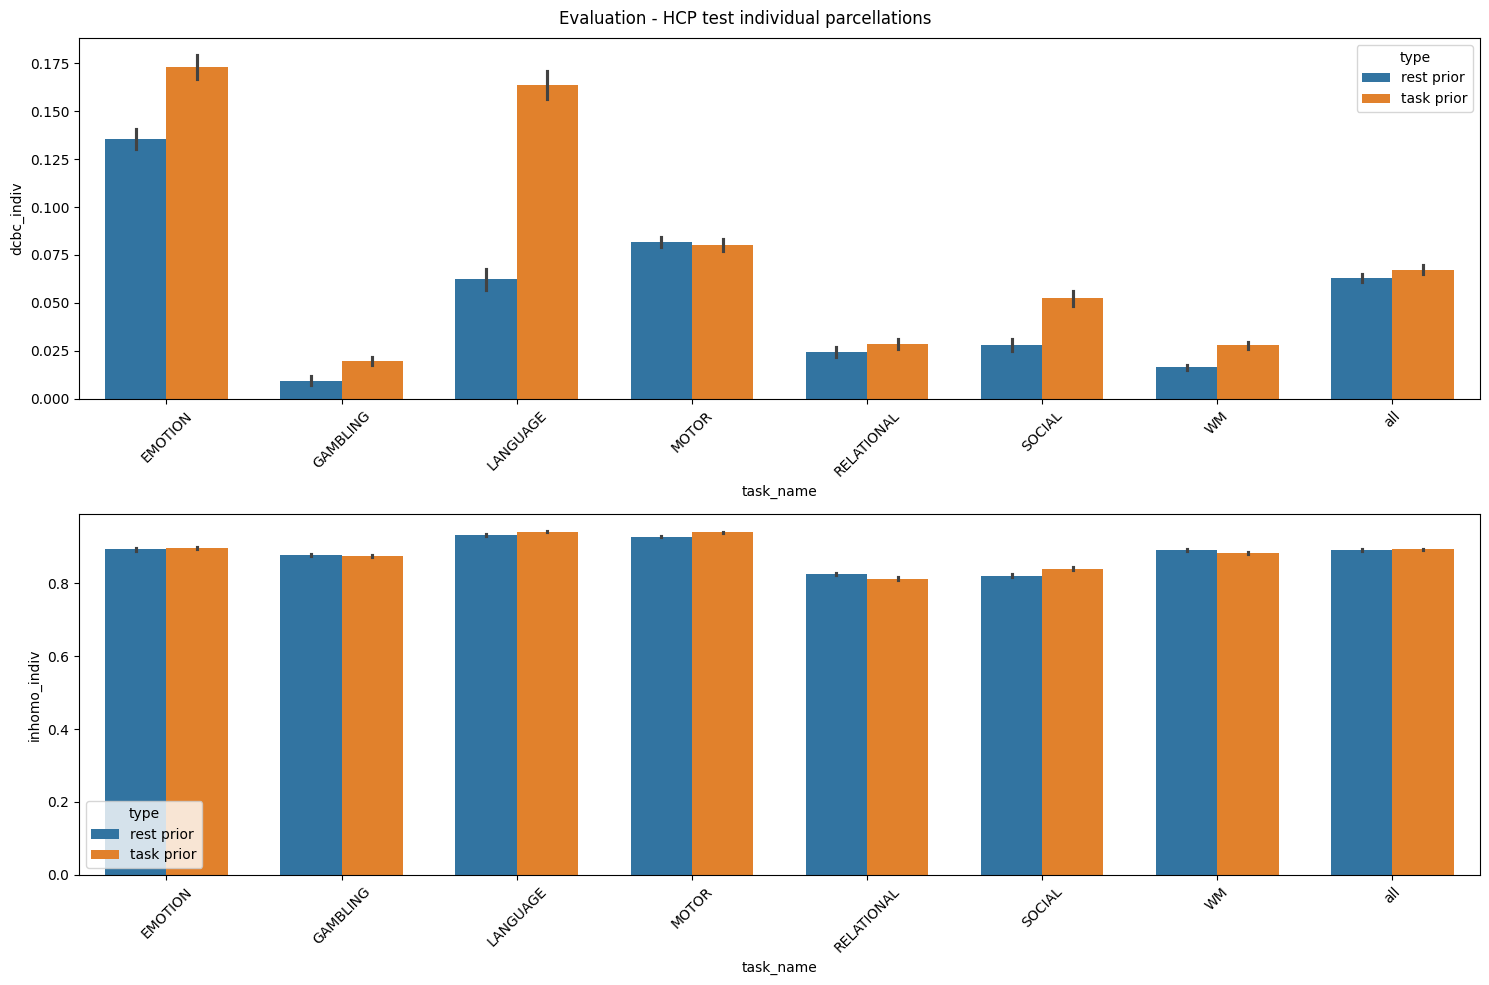

In [16]:
RES_DIR = '/data/tge/dzhi/Indiv_par/Evaluations'
results1 = pd.read_csv(RES_DIR + f'/eval_HCP800+HCPtask-half1_indiv-WcRBM_test_on_HCPtask-half2.tsv', sep='\t')
results1 = results1.loc[(results1['strength'] == 2) & (results1['spatial_w'] == 20)]
results1['type'] = 'rest prior'
results2 = pd.read_csv(RES_DIR + f'/eval_7taskfusion+HCPtask-half1_indiv-WcRBM_test_on_HCPtask-half2.tsv', sep='\t')
results2 = results2.loc[(results2['strength'] == 2) & (results2['spatial_w'] == 20)]
results2['type'] = 'task prior'

results = pd.concat([results1, results2], ignore_index=True)
print(results.task_name.unique())

# Plot results
plt.figure(figsize=(15, 10))
plt.subplot(2,1,1)
# sb.boxplot(data=results, x='network', y='dice', hue='type', width=0.7)
sb.barplot(data=results, x='task_name', y='dcbc_indiv', hue='type', errorbar='se', width=0.7)
plt.xticks(rotation=45)

plt.subplot(2,1,2)
sb.barplot(data=results, x='task_name', y='inhomo_indiv', hue='type', errorbar='se', width=0.7)
plt.xticks(rotation=45)

plt.suptitle('Evaluation - HCP test individual parcellations')
plt.tight_layout()

plt.show()

## K = 15

['EMOTION' 'GAMBLING' 'LANGUAGE' 'MOTOR' 'RELATIONAL' 'SOCIAL' 'WM' 'all']


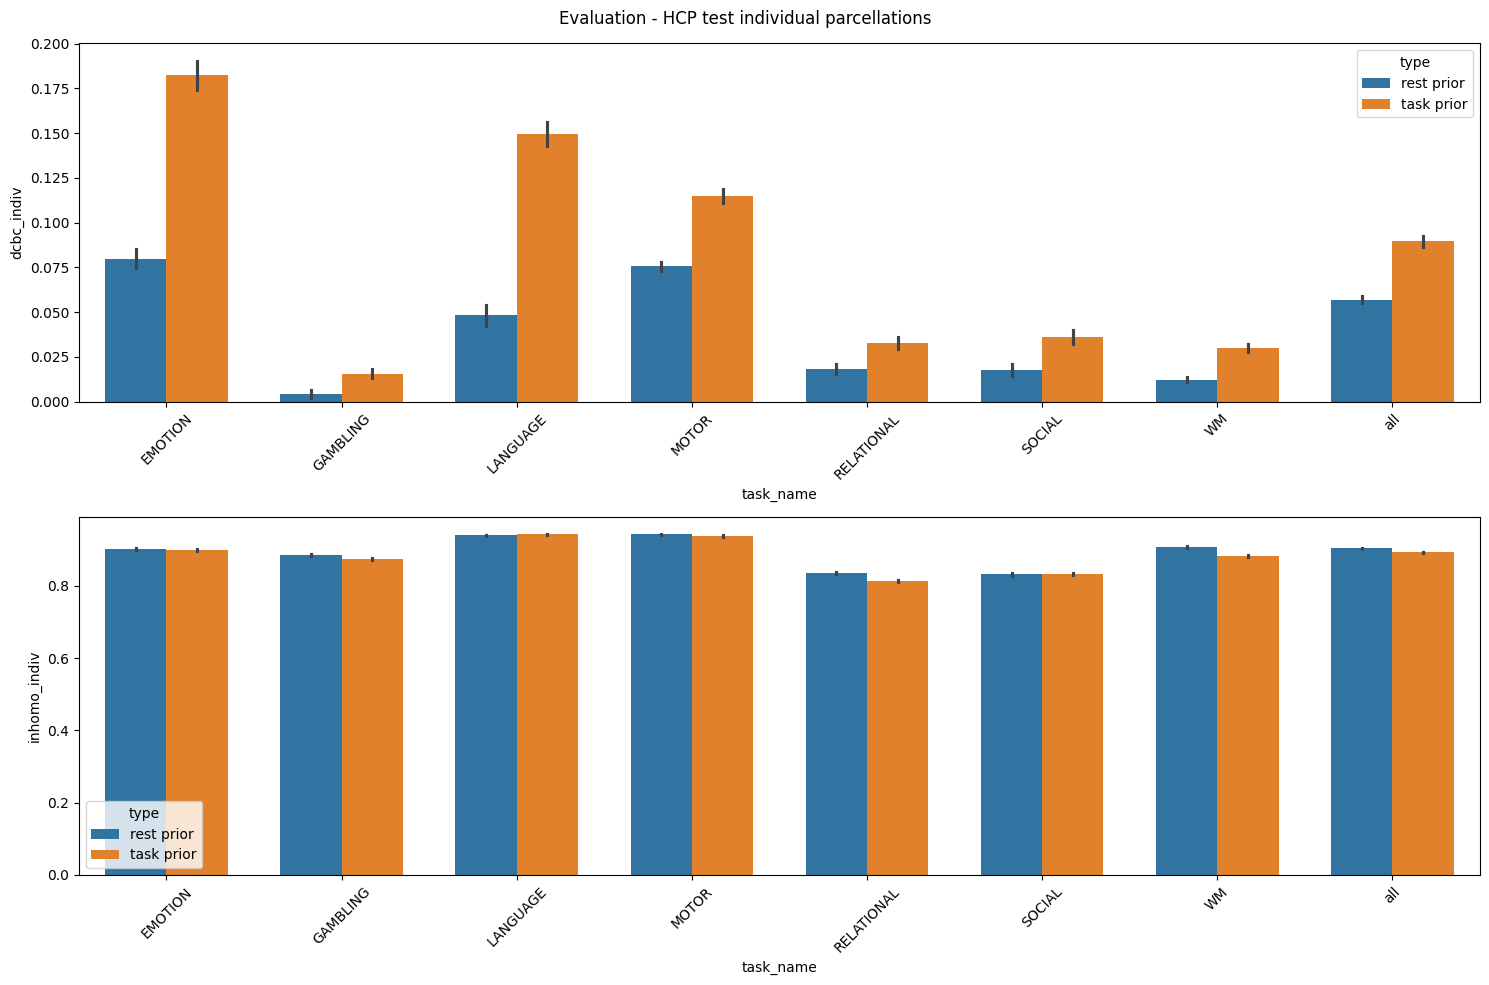

In [3]:
RES_DIR = '/data/tge/dzhi/Indiv_par/Evaluations'
results1 = pd.read_csv(RES_DIR + f'/eval_HCP40+HCPtask-half1_K-15_indiv-WcRBM_test_on_HCPtask-half2.tsv', sep='\t')
results1 = results1.loc[(results1['strength'] == 2) & (results1['spatial_w'] == 20)]
results1['type'] = 'rest prior'
results2 = pd.read_csv(RES_DIR + f'/eval_7taskfusion+HCPtask-half1_K-15_indiv-WcRBM_test_on_HCPtask-half2.tsv', sep='\t')
results2 = results2.loc[(results2['strength'] == 2) & (results2['spatial_w'] == 20)]
results2['type'] = 'task prior'

results = pd.concat([results1, results2], ignore_index=True)
print(results.task_name.unique())

# Plot results
plt.figure(figsize=(15, 10))
plt.subplot(2,1,1)
# sb.boxplot(data=results, x='network', y='dice', hue='type', width=0.7)
sb.barplot(data=results, x='task_name', y='dcbc_indiv', hue='type', errorbar='se', width=0.7)
plt.xticks(rotation=45)

plt.subplot(2,1,2)
sb.barplot(data=results, x='task_name', y='inhomo_indiv', hue='type', errorbar='se', width=0.7)
plt.xticks(rotation=45)

plt.suptitle('Evaluation - HCP test individual parcellations')
plt.tight_layout()

plt.show()

## Option 2: Precision mapping using MSC task individual data 

## (a) with resting prior

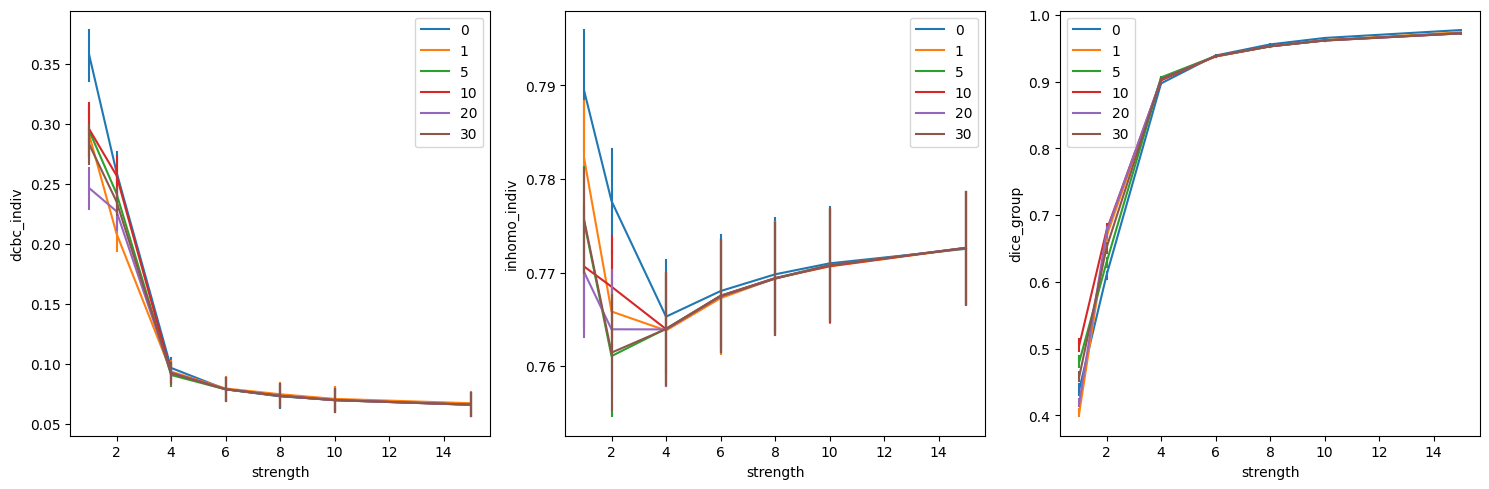

In [3]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP800+MSCtask-half1_K-17_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,2)
sb.lineplot(data=results, x="strength", y='inhomo_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

## (b) with task prior

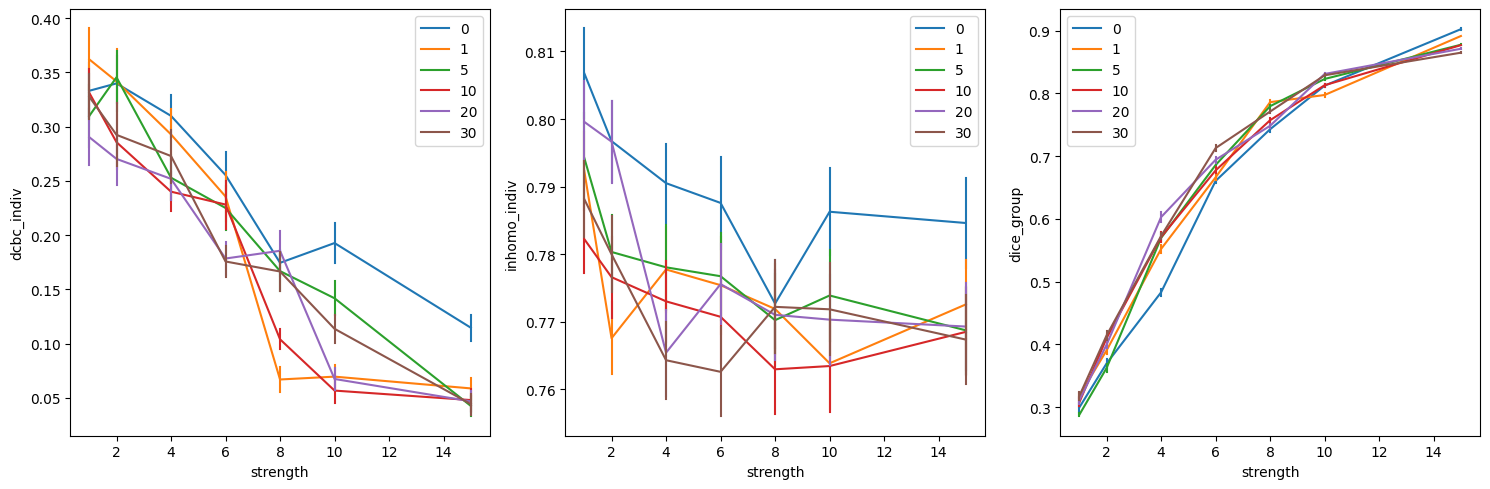

In [4]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_7taskfusion+MSCtask-half1_K-17_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,2)
sb.lineplot(data=results, x="strength", y='inhomo_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

## (c) with existing resting prior (Kong 2019)

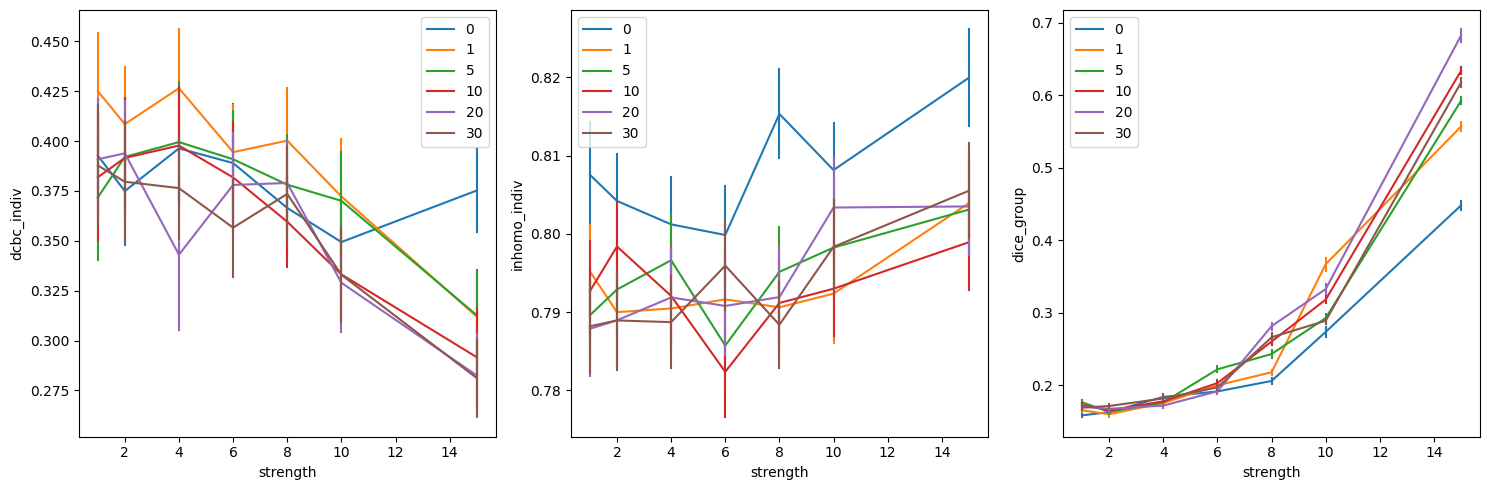

In [5]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_KONG2019+MSCtask-half1_K-17_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,2)
sb.lineplot(data=results, x="strength", y='inhomo_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

## K=17 comparison

['motor' 'mem' 'mixed' 'all']


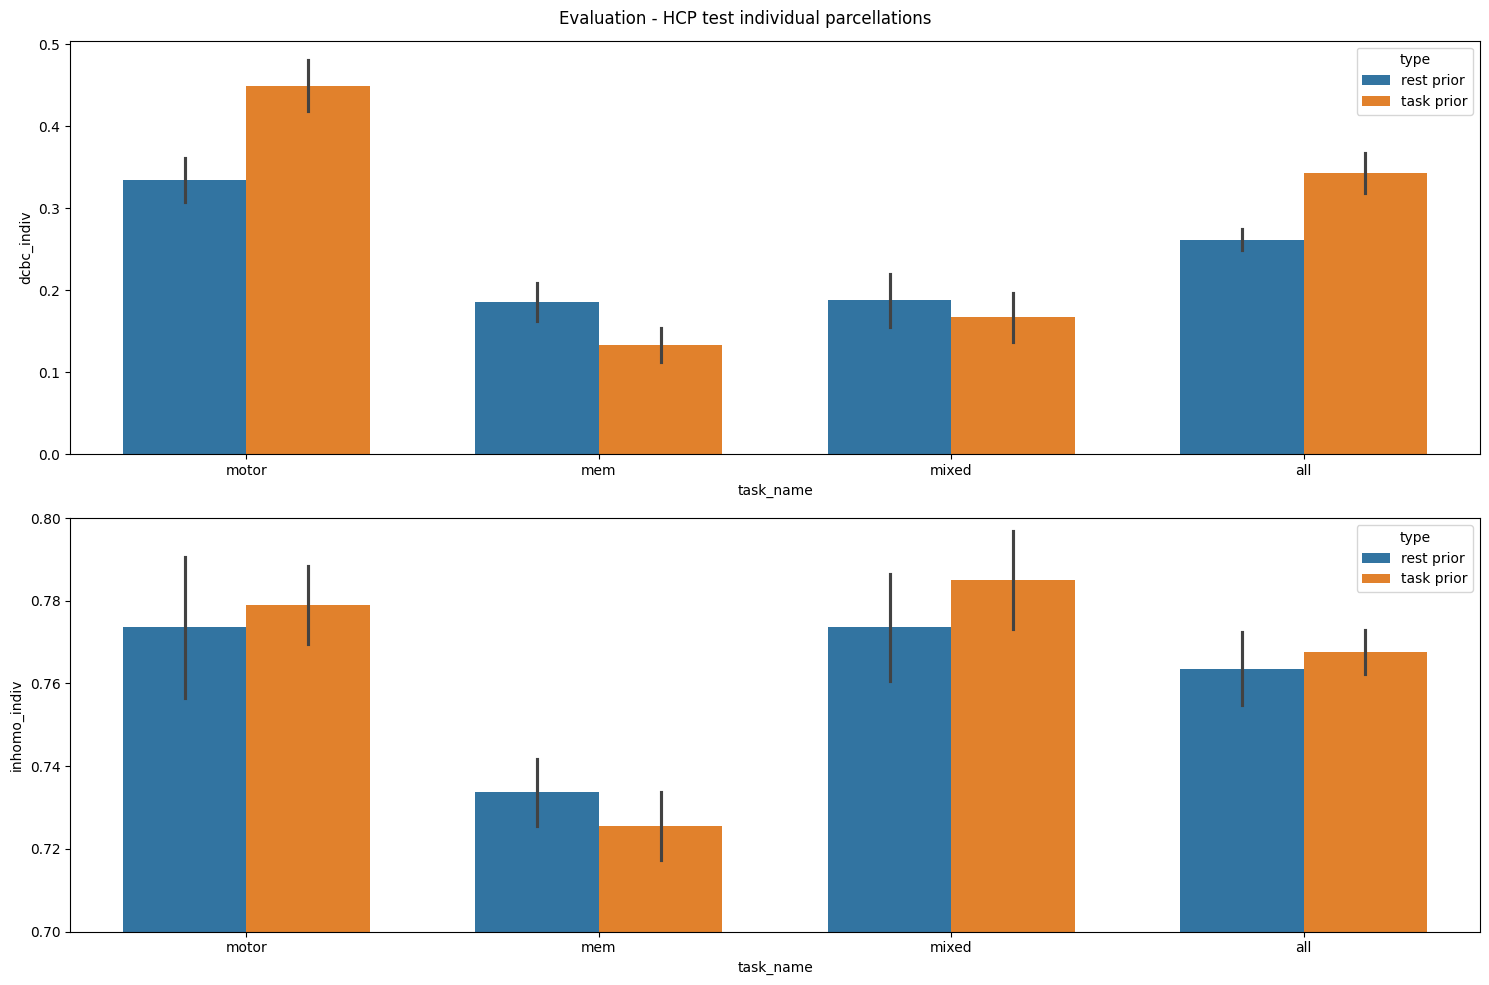

In [5]:
RES_DIR = '/data/tge/dzhi/Indiv_par/Evaluations'
results1 = pd.read_csv(RES_DIR + f'/eval_HCP800+MSCtask-half1_K-17_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')
results1 = results1.loc[(results1['strength'] == 2) & (results1['spatial_w'] == 5)]
results1['type'] = 'rest prior'

results2 = pd.read_csv(RES_DIR + f'/eval_7taskfusion+MSCtask-half1_K-17_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')
results2 = results2.loc[(results2['strength'] == 4) & (results2['spatial_w'] == 30)]
results2['type'] = 'task prior'

# results3 = pd.read_csv(RES_DIR + f'/eval_KONG2019+MSCtask-half1_K-17_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')
# results3 = results3.loc[(results3['strength'] == 2) & (results3['spatial_w'] == 5)]
# results3['type'] = 'Kong 2019 prior'

results = pd.concat([results1, results2], ignore_index=True)
print(results.task_name.unique())

# Plot results
plt.figure(figsize=(15, 10))
plt.subplot(2,1,1)
# sb.boxplot(data=results, x='network', y='dice', hue='type', width=0.7)
sb.barplot(data=results, x='task_name', y='dcbc_indiv', hue='type', errorbar='se', width=0.7)

plt.subplot(2,1,2)
sb.barplot(data=results, x='task_name', y='inhomo_indiv', hue='type', errorbar='se', width=0.7)
plt.ylim(0.7,0.8)

plt.suptitle('Evaluation - HCP test individual parcellations')
plt.tight_layout()

plt.show()

## K =15 comparison

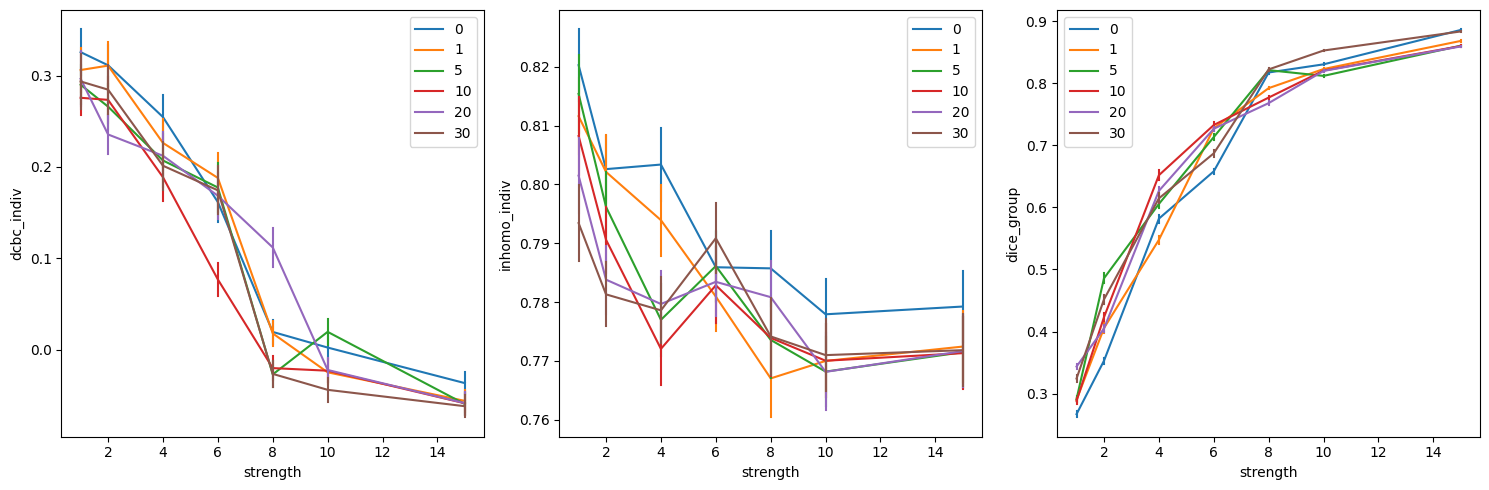

In [5]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_7taskfusion+MSCtask-half1_K-15_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,2)
sb.lineplot(data=results, x="strength", y='inhomo_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

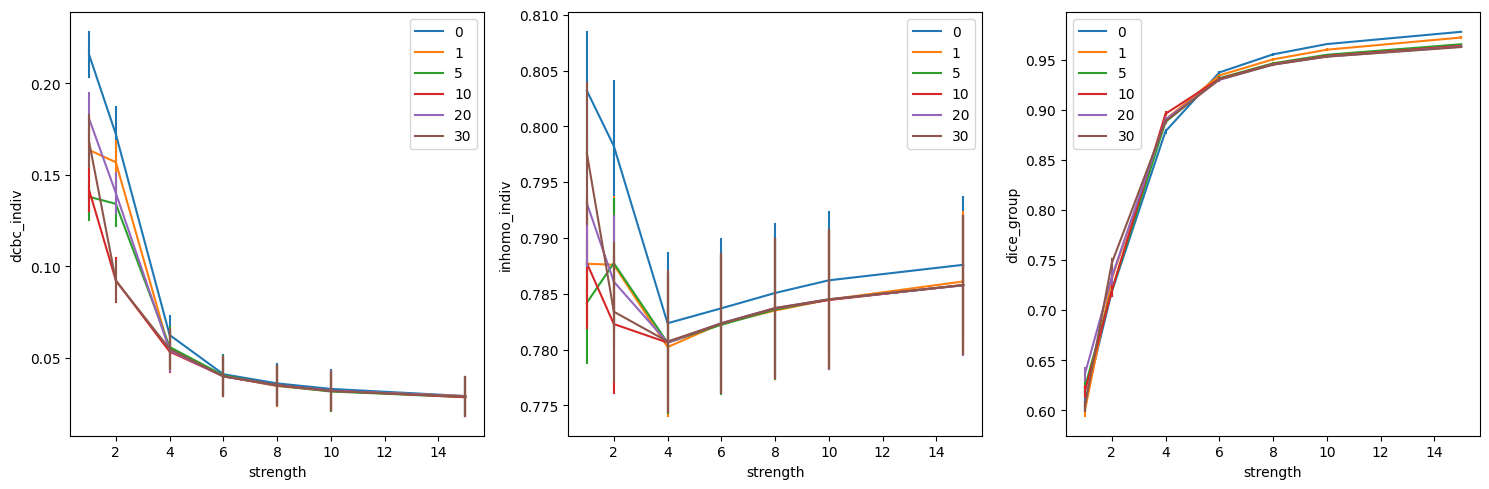

In [6]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP40+MSCtask-half1_K-15_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,2)
sb.lineplot(data=results, x="strength", y='inhomo_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

['motor' 'mem' 'mixed' 'all']


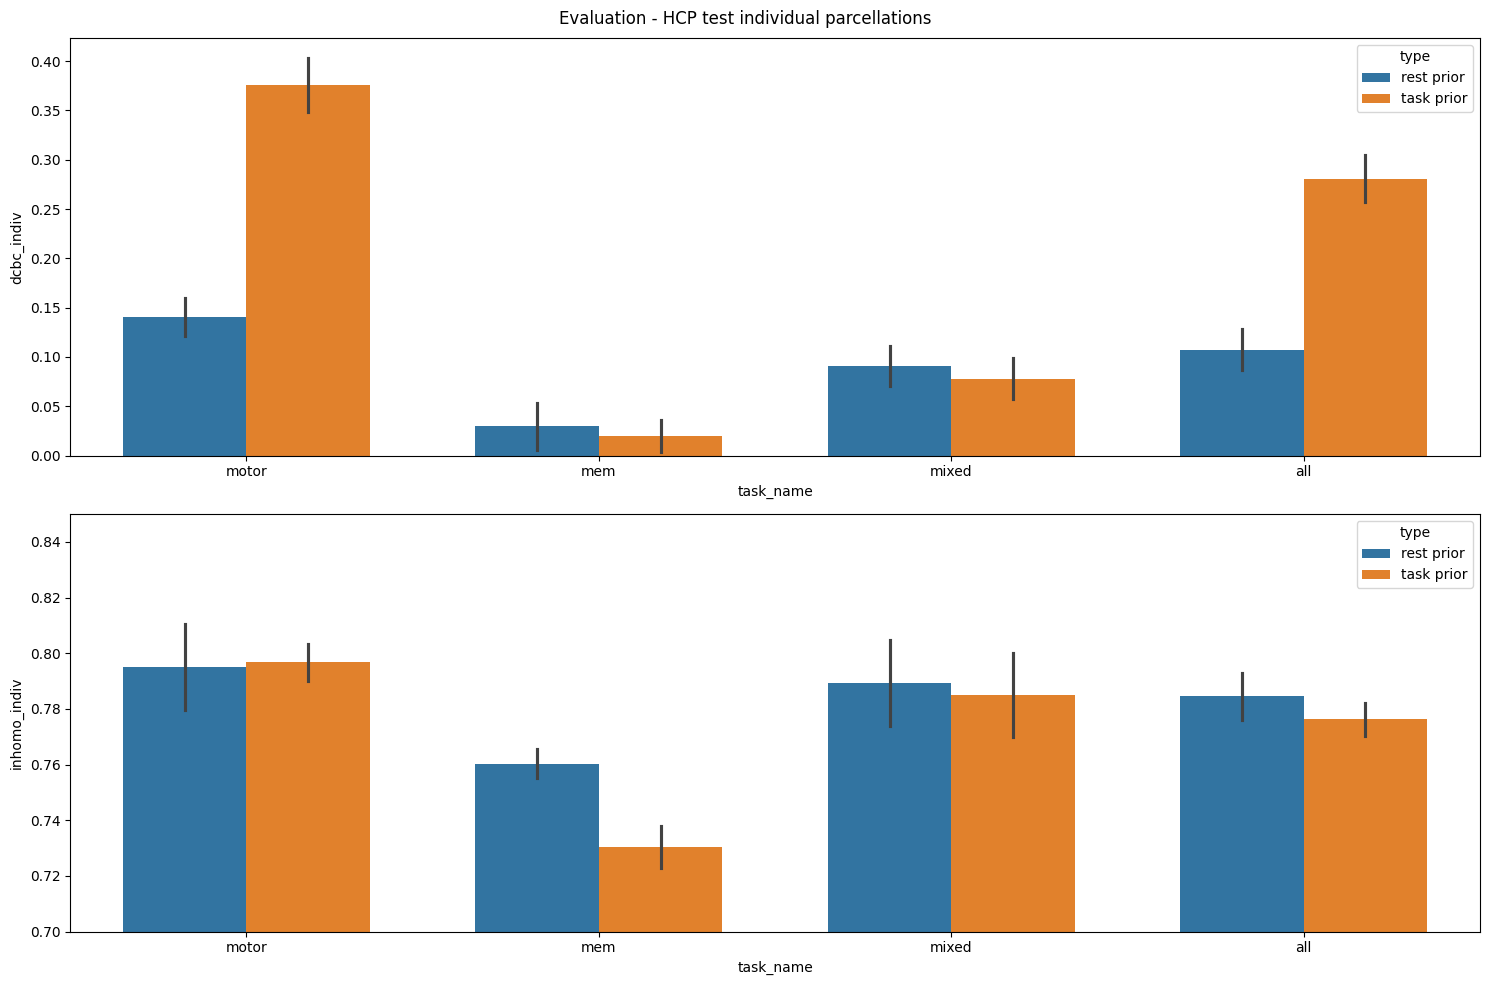

In [10]:
RES_DIR = '/data/tge/dzhi/Indiv_par/Evaluations'
results1 = pd.read_csv(RES_DIR + f'/eval_HCP40+MSCtask-half1_K-15_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')
results1 = results1.loc[(results1['strength'] == 2) & (results1['spatial_w'] == 10)]
results1['type'] = 'rest prior'

results2 = pd.read_csv(RES_DIR + f'/eval_7taskfusion+MSCtask-half1_K-15_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')
results2 = results2.loc[(results2['strength'] == 4) & (results2['spatial_w'] == 10)]
results2['type'] = 'task prior'

# results3 = pd.read_csv(RES_DIR + f'/eval_KONG2019+MSCtask-half1_K-17_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')
# results3 = results3.loc[(results3['strength'] == 2) & (results3['spatial_w'] == 5)]
# results3['type'] = 'Kong 2019 prior'

results = pd.concat([results1, results2], ignore_index=True)
print(results.task_name.unique())

# Plot results
plt.figure(figsize=(15, 10))
plt.subplot(2,1,1)
# sb.boxplot(data=results, x='network', y='dice', hue='type', width=0.7)
sb.barplot(data=results, x='task_name', y='dcbc_indiv', hue='type', errorbar='se', width=0.7)

plt.subplot(2,1,2)
sb.barplot(data=results, x='task_name', y='inhomo_indiv', hue='type', errorbar='se', width=0.7)
plt.ylim(0.7,0.85)

plt.suptitle('Evaluation - HCP test individual parcellations')
plt.tight_layout()

plt.show()

## Control - independent model

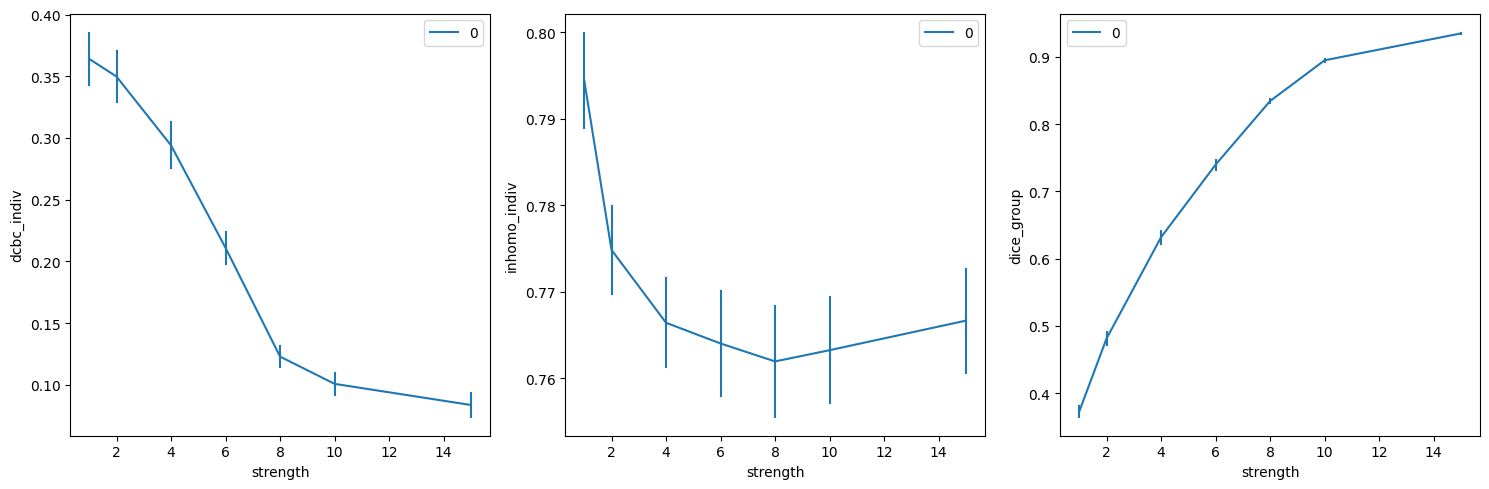

In [9]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP800+MSCtask-half1_K-17_indiv-independent_test_on_MSCtask-half2.tsv', sep='\t')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,2)
sb.lineplot(data=results, x="strength", y='inhomo_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

['motor' 'mem' 'mixed' 'all']


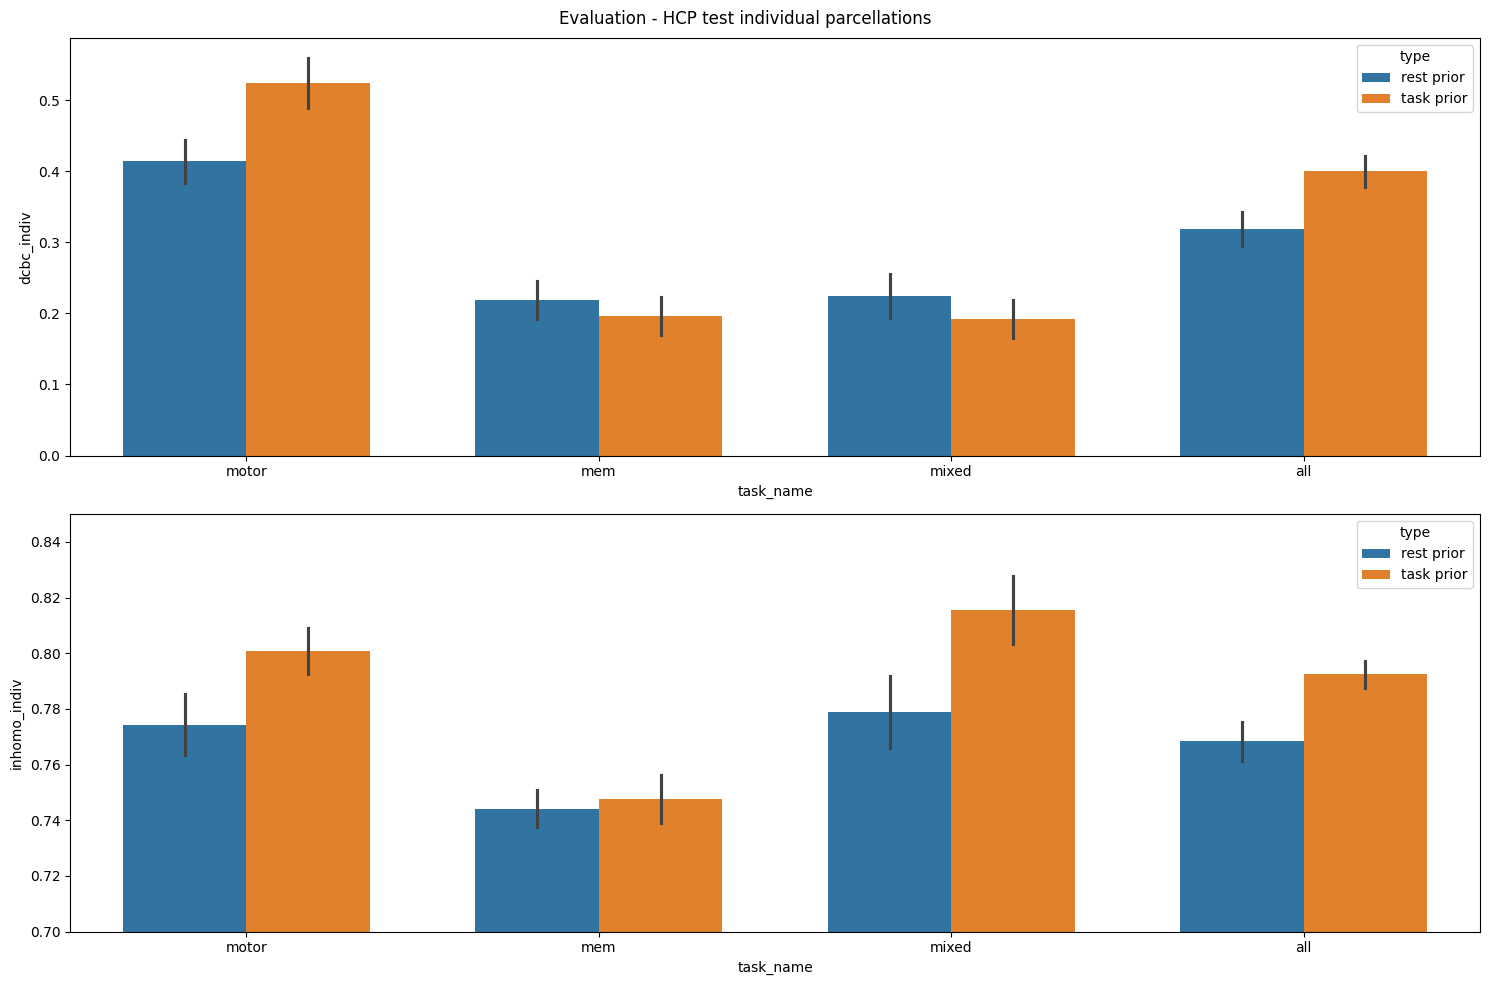

In [2]:
RES_DIR = '/data/tge/dzhi/Indiv_par/Evaluations'
results1 = pd.read_csv(RES_DIR + f'/eval_HCP800+MSCtask-half1_K-17_indiv-independent_test_on_MSCtask-half2.tsv', sep='\t')
results1 = results1.loc[(results1['strength'] == 4)]
results1['type'] = 'rest prior'

results2 = pd.read_csv(RES_DIR + f'/eval_7taskfusion+MSCtask-half1_K-17_indiv-independent_test_on_MSCtask-half2.tsv', sep='\t')
results2 = results2.loc[(results2['strength'] == 4)]
results2['type'] = 'task prior'

# results3 = pd.read_csv(RES_DIR + f'/eval_KONG2019+MSCtask-half1_K-17_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')
# results3 = results3.loc[(results3['strength'] == 2) & (results3['spatial_w'] == 5)]
# results3['type'] = 'Kong 2019 prior'

results = pd.concat([results1, results2], ignore_index=True)
print(results.task_name.unique())

# Plot results
plt.figure(figsize=(15, 10))
plt.subplot(2,1,1)
# sb.boxplot(data=results, x='network', y='dice', hue='type', width=0.7)
sb.barplot(data=results, x='task_name', y='dcbc_indiv', hue='type', errorbar='se', width=0.7)

plt.subplot(2,1,2)
sb.barplot(data=results, x='task_name', y='inhomo_indiv', hue='type', errorbar='se', width=0.7)
plt.ylim(0.7,0.85)

plt.suptitle('Evaluation - HCP test individual parcellations')
plt.tight_layout()

plt.show()

In [4]:
dat, info, _ = ds.get_dataset('/data/tge/Tian/UKBB_full/imaging', 'MDTB',
                                    atlas='fs32k', sess='ses-s1',
                                    type='CondHalf', subj=None, smooth='6fwhm_zstat_masked-hi0.1lo0.1')

# QC
import Functional_Fusion.reliability as rel
rw = rel.within_subj(np.nan_to_num(dat), cond_vec=info.cond_num, part_vec=info.half,
                     separate='condition_wise', subtract_mean=True)
cond_mask = np.where(rw <= 0.5, False, True)
cond_mask = np.hstack((cond_mask, cond_mask.copy()))
dat[~cond_mask, :] = np.nan

print(f'{np.sum(~cond_mask)}/{cond_mask.size} contrasts, drop rate {np.sum(~cond_mask)/cond_mask.size}')


172/1392 contrasts, drop rate 0.1235632183908046


the minimum reliability is 0.13091804203814925 at (np.int64(23), np.int64(21))
the minimum reliability is 0.933937967096587 at (np.int64(6), np.int64(20))


half                            1
cond_num                       22
n_rep                         8.0
instruction                     0
task_name                  stroop
cond_name             StroopIncon
task_num                       14
reg_id                         35
study                           1
cond_num_uni                   22
task_num_uni                   14
common                          0
names           StroopIncon-half1
cond_code               strpincon
sess                       ses-s1
Name: 21, dtype: object

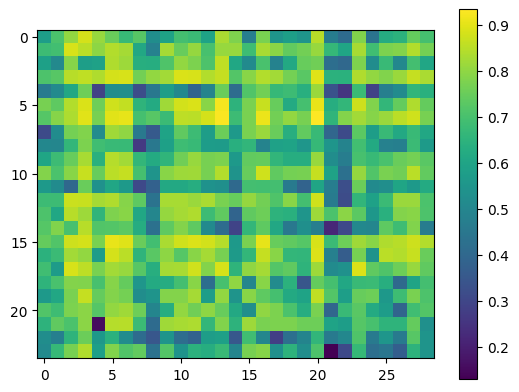

In [24]:
plt.imshow(rw)
plt.colorbar()
print(f'the minimum reliability is {np.min(rw)} at {np.unravel_index(np.argmin(rw), rw.shape)}')
print(f'the minimum reliability is {np.max(rw)} at {np.unravel_index(np.argmax(rw), rw.shape)}')
info.iloc[21]

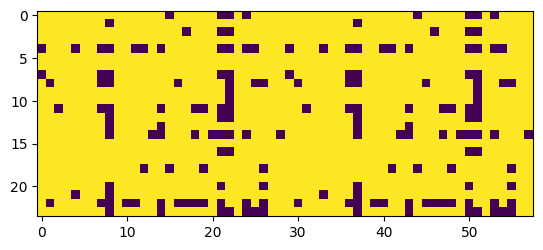

In [8]:
plt.imshow(cond_mask)

# K=17, Resting prior + individual data (pure rest, pure task, rest+task)

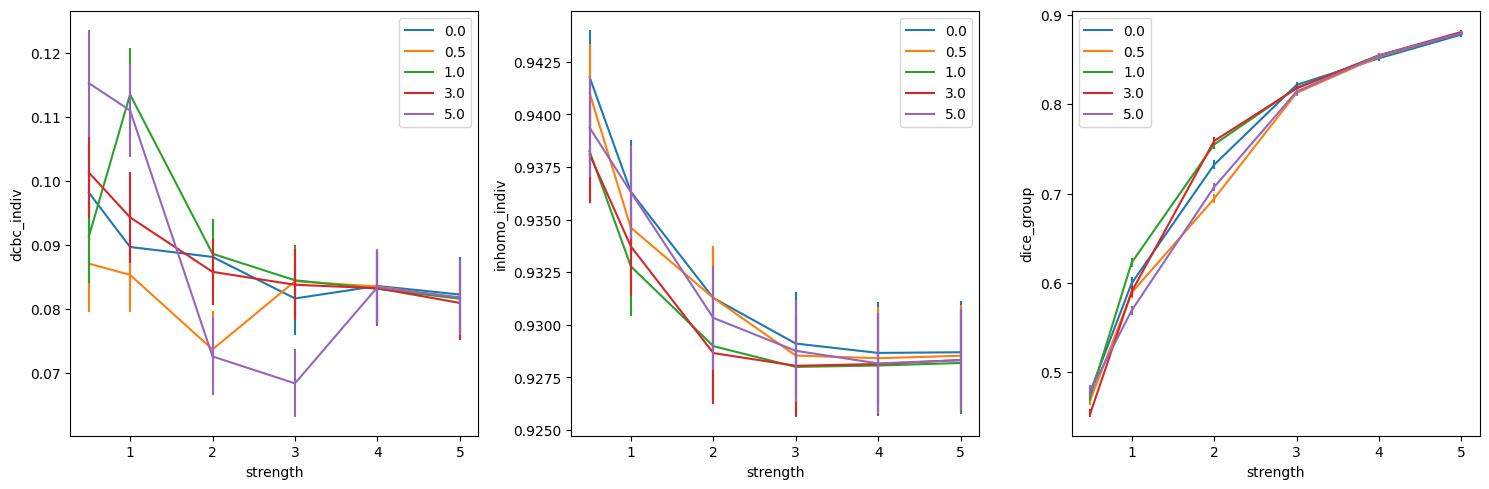

In [11]:
# eval_HCP800+HCPrest+task_K-17_indiv-mRBM_test_on_HCPtask-contrast.tsv
# eval_HCP800+HCPrest-2run_K-17_indiv-mRBM_test_on_HCPtask-contrast.tsv
# eval_HCP800+HCPtask-2run_K-17_indiv-mRBM_test_on_HCPtask-contrast.tsv

results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP800+HCPtask-2run_K-17_indiv-mRBM_test_on_HCPtask-contrast.tsv', sep='\t')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,2)
sb.lineplot(data=results, x="strength", y='inhomo_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

['all']


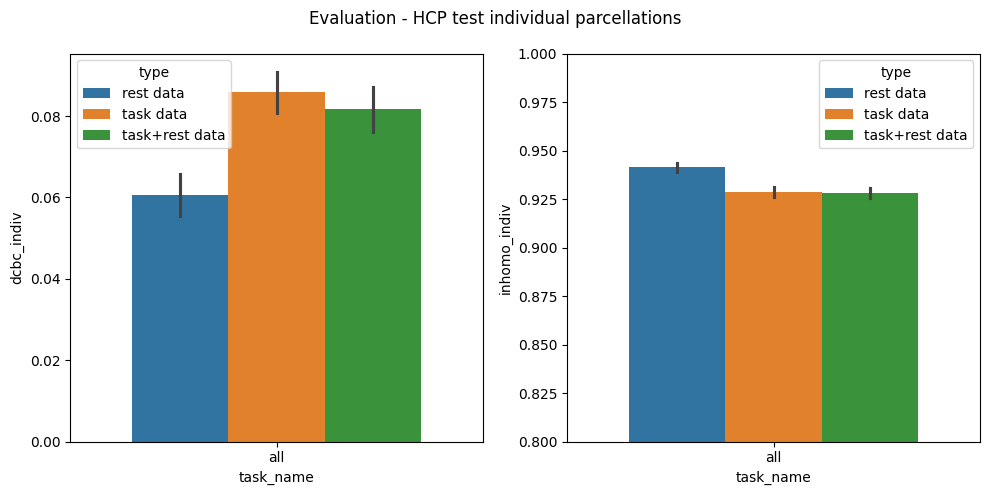

In [15]:
RES_DIR = '/data/tge/dzhi/Indiv_par/Evaluations'

results1 = pd.read_csv(RES_DIR + f'/eval_HCP800+HCPrest-2run_K-17_indiv-mRBM_test_on_HCPtask-contrast.tsv', sep='\t')
results1 = results1.loc[(results1['strength'] == 2) & (results1['spatial_w'] == 5)]
results1['type'] = 'rest data'

results2 = pd.read_csv(RES_DIR + f'/eval_HCP800+HCPtask-2run_K-17_indiv-mRBM_test_on_HCPtask-contrast.tsv', sep='\t')
results2 = results2.loc[(results2['strength'] == 2) & (results2['spatial_w'] == 3)]
results2['type'] = 'task data'

results3 = pd.read_csv(RES_DIR + f'/eval_HCP800+HCPrest+task_K-17_indiv-mRBM_test_on_HCPtask-contrast.tsv', sep='\t')
results3 = results3.loc[(results3['strength'] == 2) & (results3['spatial_w'] == 1)]
results3['type'] = 'task+rest data'

# results3 = pd.read_csv(RES_DIR + f'/eval_KONG2019+MSCtask-half1_K-17_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')
# results3 = results3.loc[(results3['strength'] == 2) & (results3['spatial_w'] == 5)]
# results3['type'] = 'Kong 2019 prior'

results = pd.concat([results1, results2, results3], ignore_index=True)
print(results.task_name.unique())

# Plot results
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
# sb.boxplot(data=results, x='network', y='dice', hue='type', width=0.7)
sb.barplot(data=results, x='task_name', y='dcbc_indiv', hue='type', errorbar='se', width=0.7)

plt.subplot(1,2,2)
sb.barplot(data=results, x='task_name', y='inhomo_indiv', hue='type', errorbar='se', width=0.7)
plt.ylim(0.8,1.0)

plt.suptitle('Evaluation - HCP test individual parcellations')
plt.tight_layout()

plt.show()

## Mean Z value

In [3]:
def plot_zvalues(input, contrast_idx, t_info, parcel_name=None):
    # Validate input
    assert input.ndim == 3, "Input tensor must be 3D: (subjects, parcels, contrasts)"
    num_subjects, num_parcels, num_contrasts = input.shape
    assert 0 <= contrast_idx < num_contrasts, "Invalid contrast index"

    # Extract the data for the given contrast
    data = input[:, :, contrast_idx]  # shape: (num_subjects, number_parcels)

    # Create parcel labels if not provided
    if parcel_name is None:
        parcel_name = [f'Parcel {i}' for i in range(num_parcels)]
    else:
        assert len(parcel_name) == num_parcels, 'Invalid parcel names'

    # Create DataFrame for plotting
    df = pd.DataFrame()        
    for i in range(num_parcels):
        this_df = pd.DataFrame({'subject': np.arange(num_subjects),
            'parcel': parcel_name[i],
            'z_value': data[:,i],
            'domain': t_info.iloc[contrast_idx].task_name
        })
        df = pd.concat([df, this_df], ignore_index=True)

    df['contrast_name'] = t_info.iloc[contrast_idx].contrast_name

    return df

In [13]:
import sys
sys.path.append('/PHShome/dz010/Workspace/IndividualParcellation/scripts')

from IndividualParcellation.scripts.indiv_eval_hcp import *
HCP_DIR = '/data/tge/Tian/HCP_img'

align, net_name, colors = get_kong2019_17_parcellation()
t_data, t_info = load_hcp_contrasts(HCP_DIR, "/subj_list/HCP203_test_set_filtered_1.tsv", space='fs32k',
                                    hemis='L', smooth='2_MSMAll')
pd.set_option('display.max_rows', None)
t_info

pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1


,contrast_name,task_name
0,FACES-SHAPES_hp200_s2_MSMAll,EMOTION
1,neg_FACES_hp200_s2_MSMAll,EMOTION
2,neg_SHAPES_hp200_s2_MSMAll,EMOTION
3,SHAPES-FACES_hp200_s2_MSMAll,EMOTION
4,PUNISH-REWARD_hp200_s2_MSMAll,GAMBLING
5,neg_PUNISH_hp200_s2_MSMAll,GAMBLING
6,neg_REWARD_hp200_s2_MSMAll,GAMBLING
7,REWARD-PUNISH_hp200_s2_MSMAll,GAMBLING
8,MATH-STORY_hp200_s2_MSMAll,LANGUAGE
9,STORY-MATH_hp200_s2_MSMAll,LANGUAGE


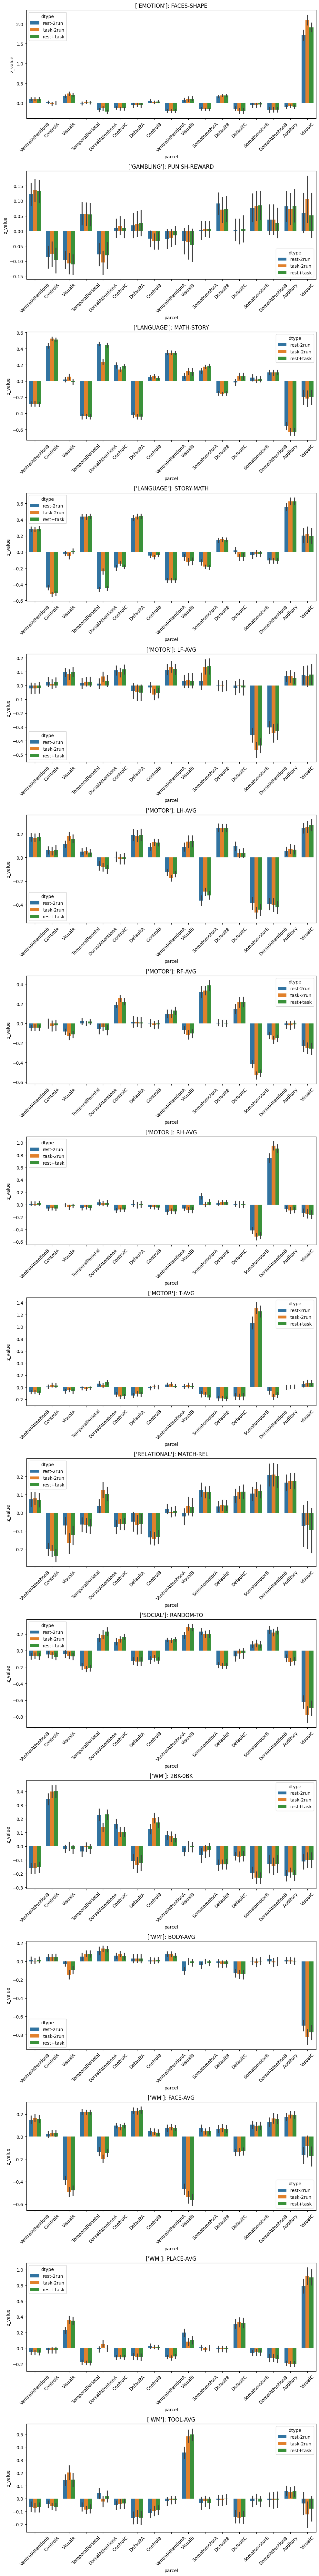

In [28]:
d_type = ['rest-2run', 'task-2run', 'rest+task']
res1 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/HCP203_test_set/zvalues' +
              '/zvalue_indiv_asym_HCP800+HCPrest-2run-indiv_K-17_strengh-2_spatial-5.npy')

res2 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/HCP203_test_set/zvalues' +
              '/zvalue_indiv_asym_HCP800+HCPtask-2run-indiv_K-17_strengh-2_spatial-3.npy')

res3 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/HCP203_test_set/zvalues' +
              '/zvalue_indiv_asym_HCP800+HCPrest+task-indiv_K-17_strengh-2_spatial-1.npy')

df_all = pd.DataFrame()
for j, res in enumerate([res1,res2,res3]):
    for i in [0,4,8,9,14,15,16,17,18,32,36,42,50,51,52,53]:
        df = plot_zvalues(res, i, t_info, parcel_name=net_name[1:])
        df['dtype'] = d_type[j]
        df_all = pd.concat([df_all, df], ignore_index=True)

df_all['contrast_name']=[s.rstrip('_hp200_s2_MSMAll') for s in df_all.contrast_name]

con_nam = df_all['contrast_name'].unique()

plt.figure(figsize=(10, 5 * len(con_nam)))

for n, c_name in enumerate(con_nam):
    this_df_all = df_all.loc[df_all['contrast_name']==c_name]
    domain = this_df_all['domain'].unique()
    
    plt.subplot(len(con_nam),1,n+1)
    sb.barplot(data=this_df_all, x='parcel', y='z_value', hue='dtype', errorbar='se', width=0.7)
    plt.xticks(rotation=45)
    plt.title(f'{domain}: {c_name}')


plt.tight_layout()
plt.show()

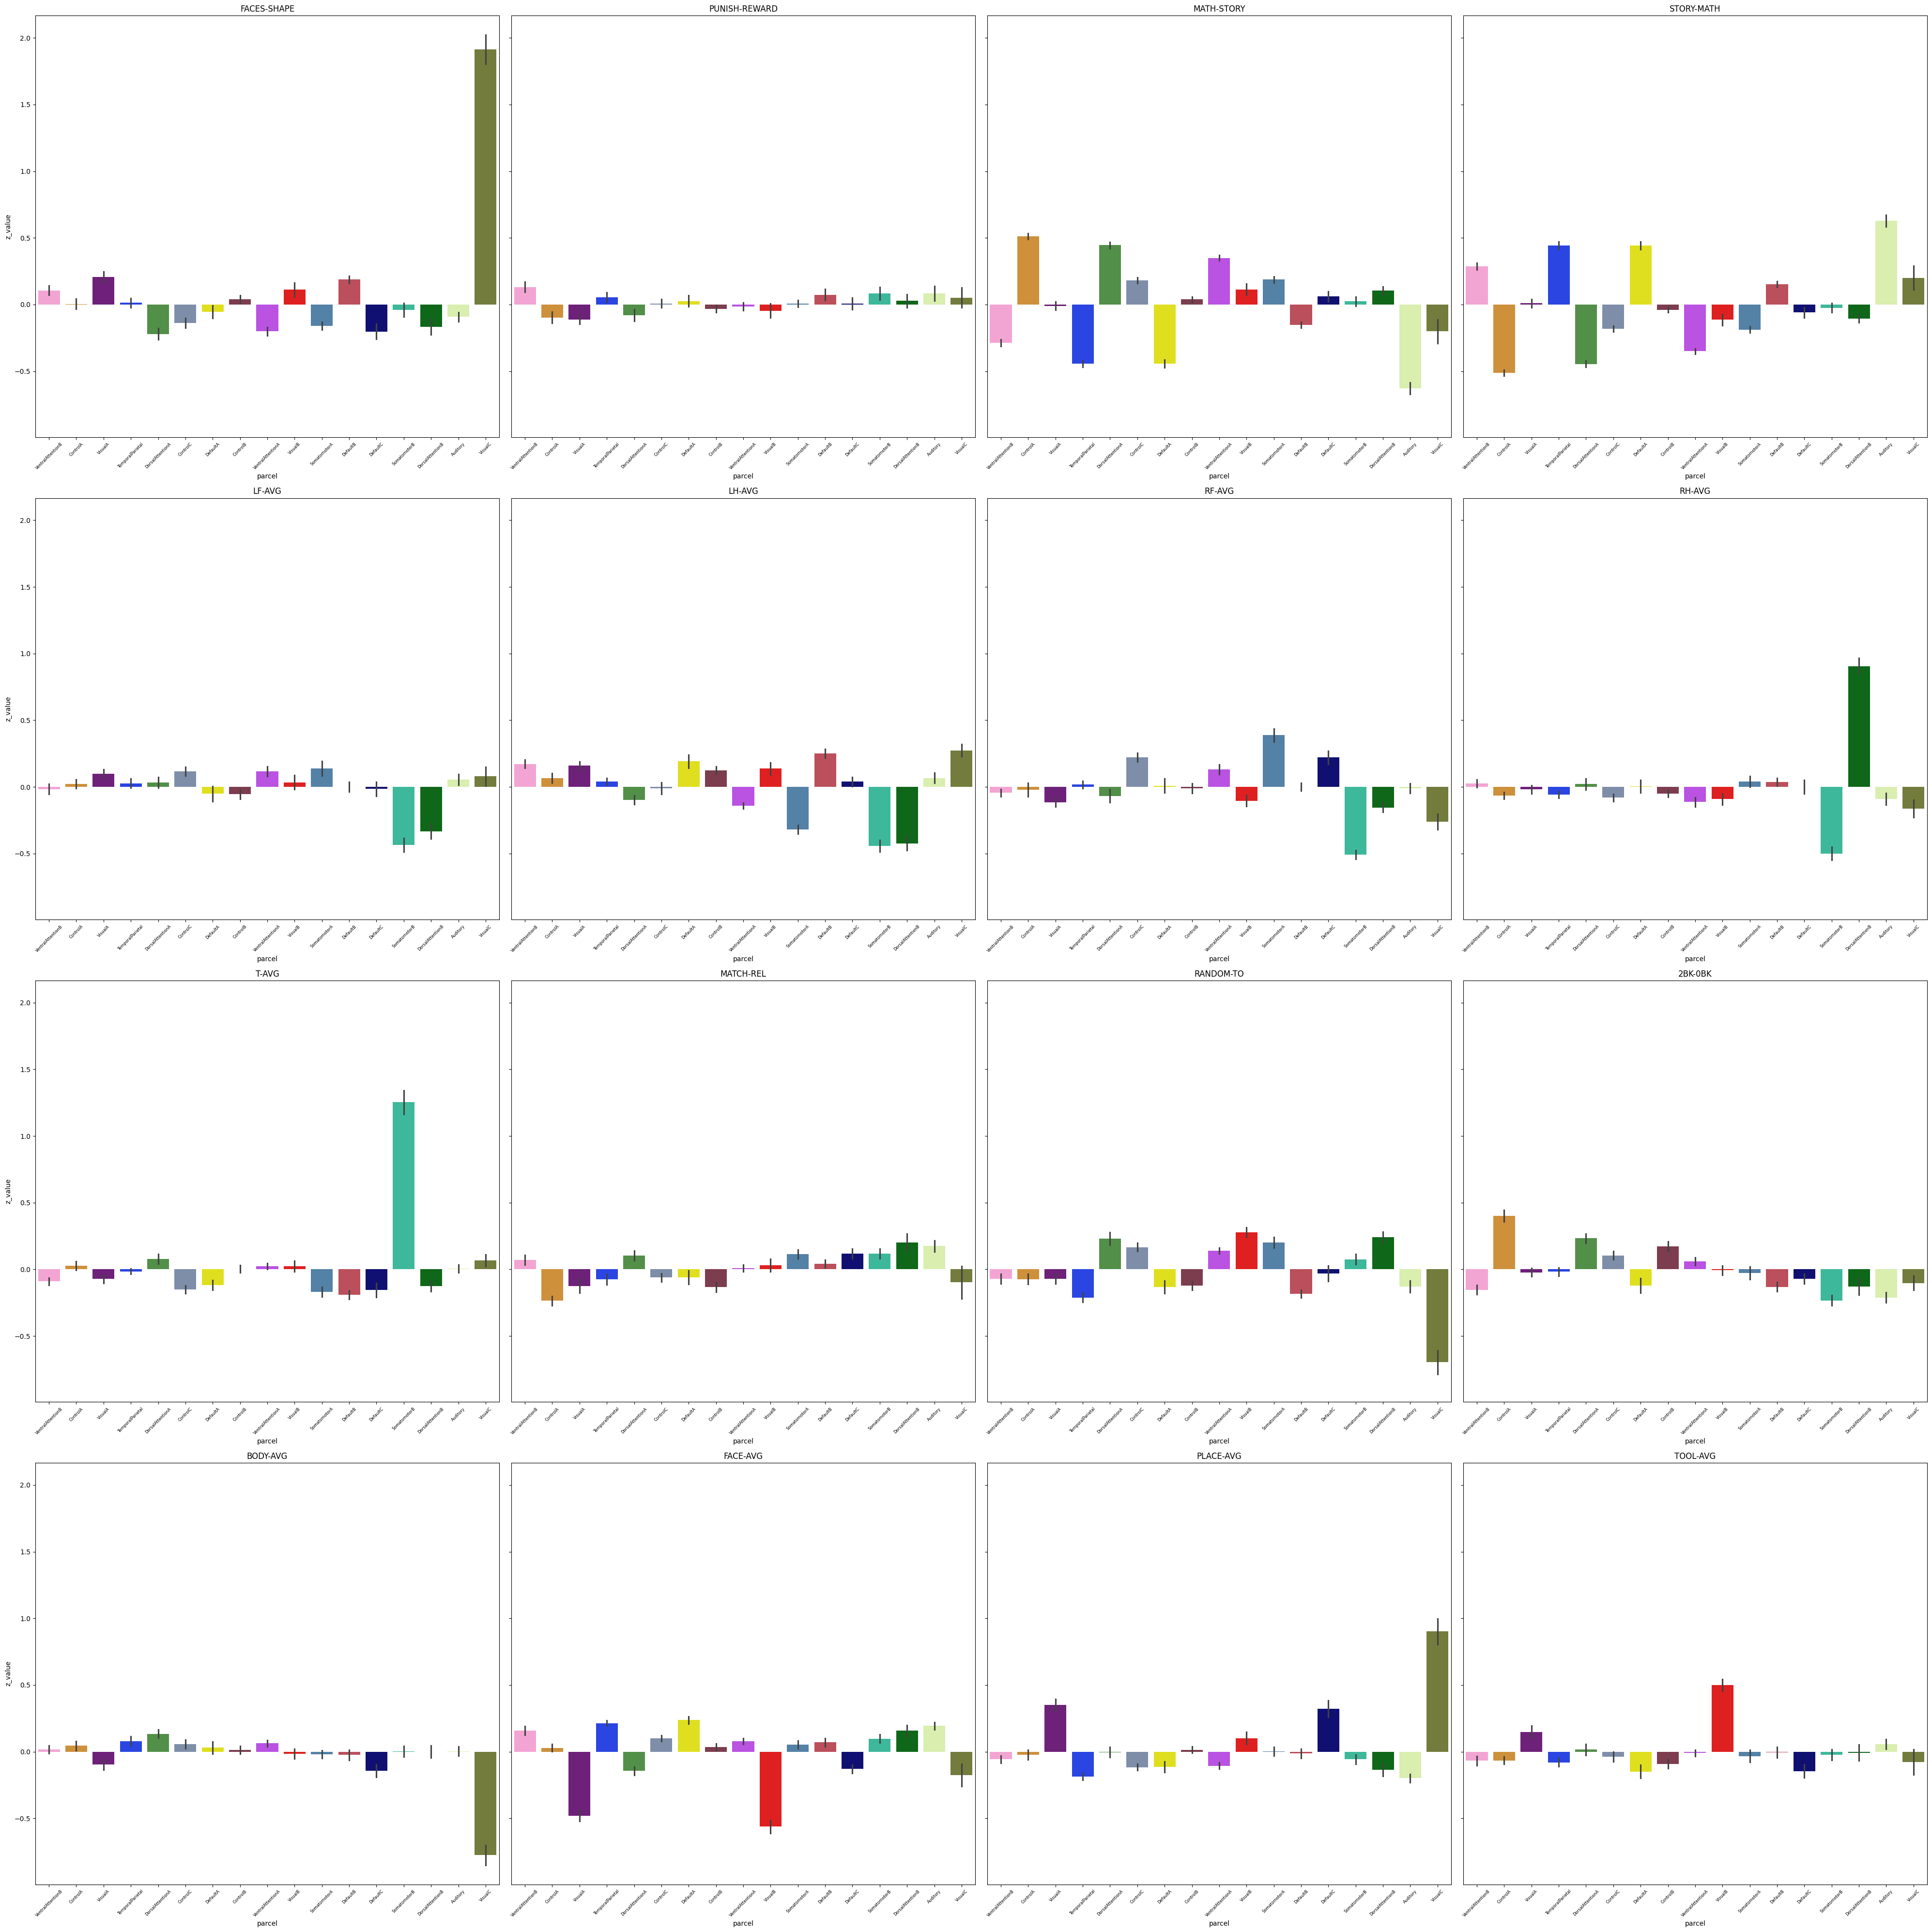

In [19]:
color_list = [tuple(color) for color in colors[1:,:]]

num_contrasts = df_all["contrast_name"].unique()
rows, cols = 4, 4
fig, axes = plt.subplots(rows, cols, figsize=(40, 40), sharey=True)
axes = axes.flatten()

for i, contrast_idx in enumerate(num_contrasts):
    ax = axes[i]
    sub_df = df_all[(df_all["contrast_name"] == contrast_idx) & (df_all["dtype"] == 'rest+task')]
    sb.barplot(data=sub_df, x='parcel', y='z_value', errorbar='se', palette=color_list, ax=ax)
    ax.set_title(f'{contrast_idx}')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=6)

# Turn off unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# K=15, HCP40 Resting prior + individual data (pure rest, pure task, rest+task)

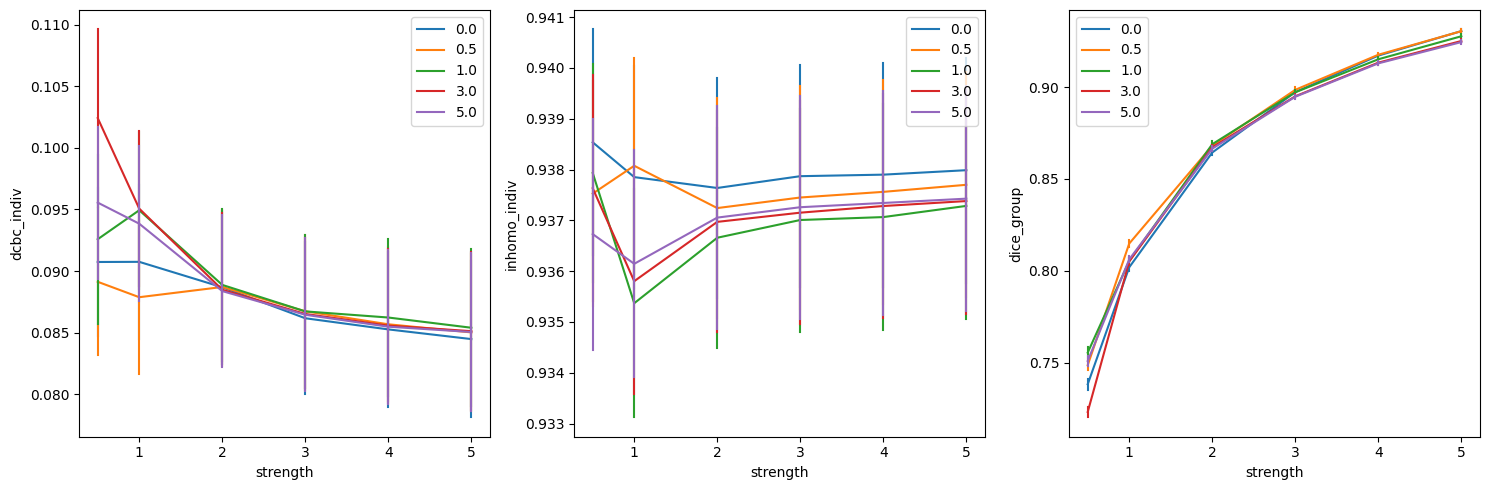

In [35]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP800+HCPrest+task_K-15_indiv-mRBM_test_on_HCPtask-contrast.tsv', sep='\t')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,2)
sb.lineplot(data=results, x="strength", y='inhomo_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

['all']


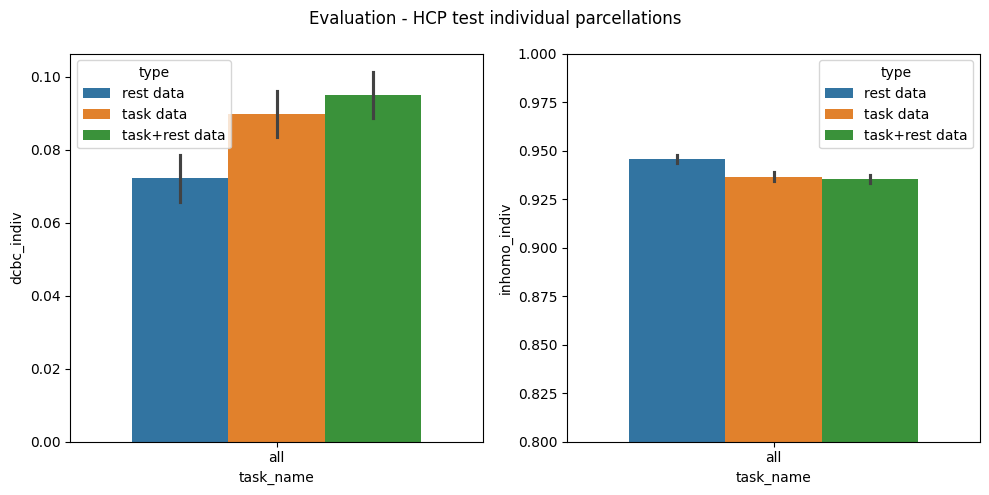

In [29]:
RES_DIR = '/data/tge/dzhi/Indiv_par/Evaluations'

results1 = pd.read_csv(RES_DIR + f'/eval_HCP800+HCPrest-2run_K-15_indiv-mRBM_test_on_HCPtask-contrast.tsv', sep='\t')
results1 = results1.loc[(results1['strength'] == 2) & (results1['spatial_w'] == 5)]
results1['type'] = 'rest data'

results2 = pd.read_csv(RES_DIR + f'/eval_HCP800+HCPtask-2run_K-15_indiv-mRBM_test_on_HCPtask-contrast.tsv', sep='\t')
results2 = results2.loc[(results2['strength'] == 2) & (results2['spatial_w'] == 1)]
results2['type'] = 'task data'

results3 = pd.read_csv(RES_DIR + f'/eval_HCP800+HCPrest+task_K-15_indiv-mRBM_test_on_HCPtask-contrast.tsv', sep='\t')
results3 = results3.loc[(results3['strength'] == 1) & (results3['spatial_w'] == 1)]
results3['type'] = 'task+rest data'

# results3 = pd.read_csv(RES_DIR + f'/eval_KONG2019+MSCtask-half1_K-17_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')
# results3 = results3.loc[(results3['strength'] == 2) & (results3['spatial_w'] == 5)]
# results3['type'] = 'Kong 2019 prior'

results = pd.concat([results1, results2, results3], ignore_index=True)
print(results.task_name.unique())

# Plot results
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
# sb.boxplot(data=results, x='network', y='dice', hue='type', width=0.7)
sb.barplot(data=results, x='task_name', y='dcbc_indiv', hue='type', errorbar='se', width=0.7)

plt.subplot(1,2,2)
sb.barplot(data=results, x='task_name', y='inhomo_indiv', hue='type', errorbar='se', width=0.7)
plt.ylim(0.8,1.0)

plt.suptitle('Evaluation - HCP test individual parcellations')
plt.tight_layout()

plt.show()

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


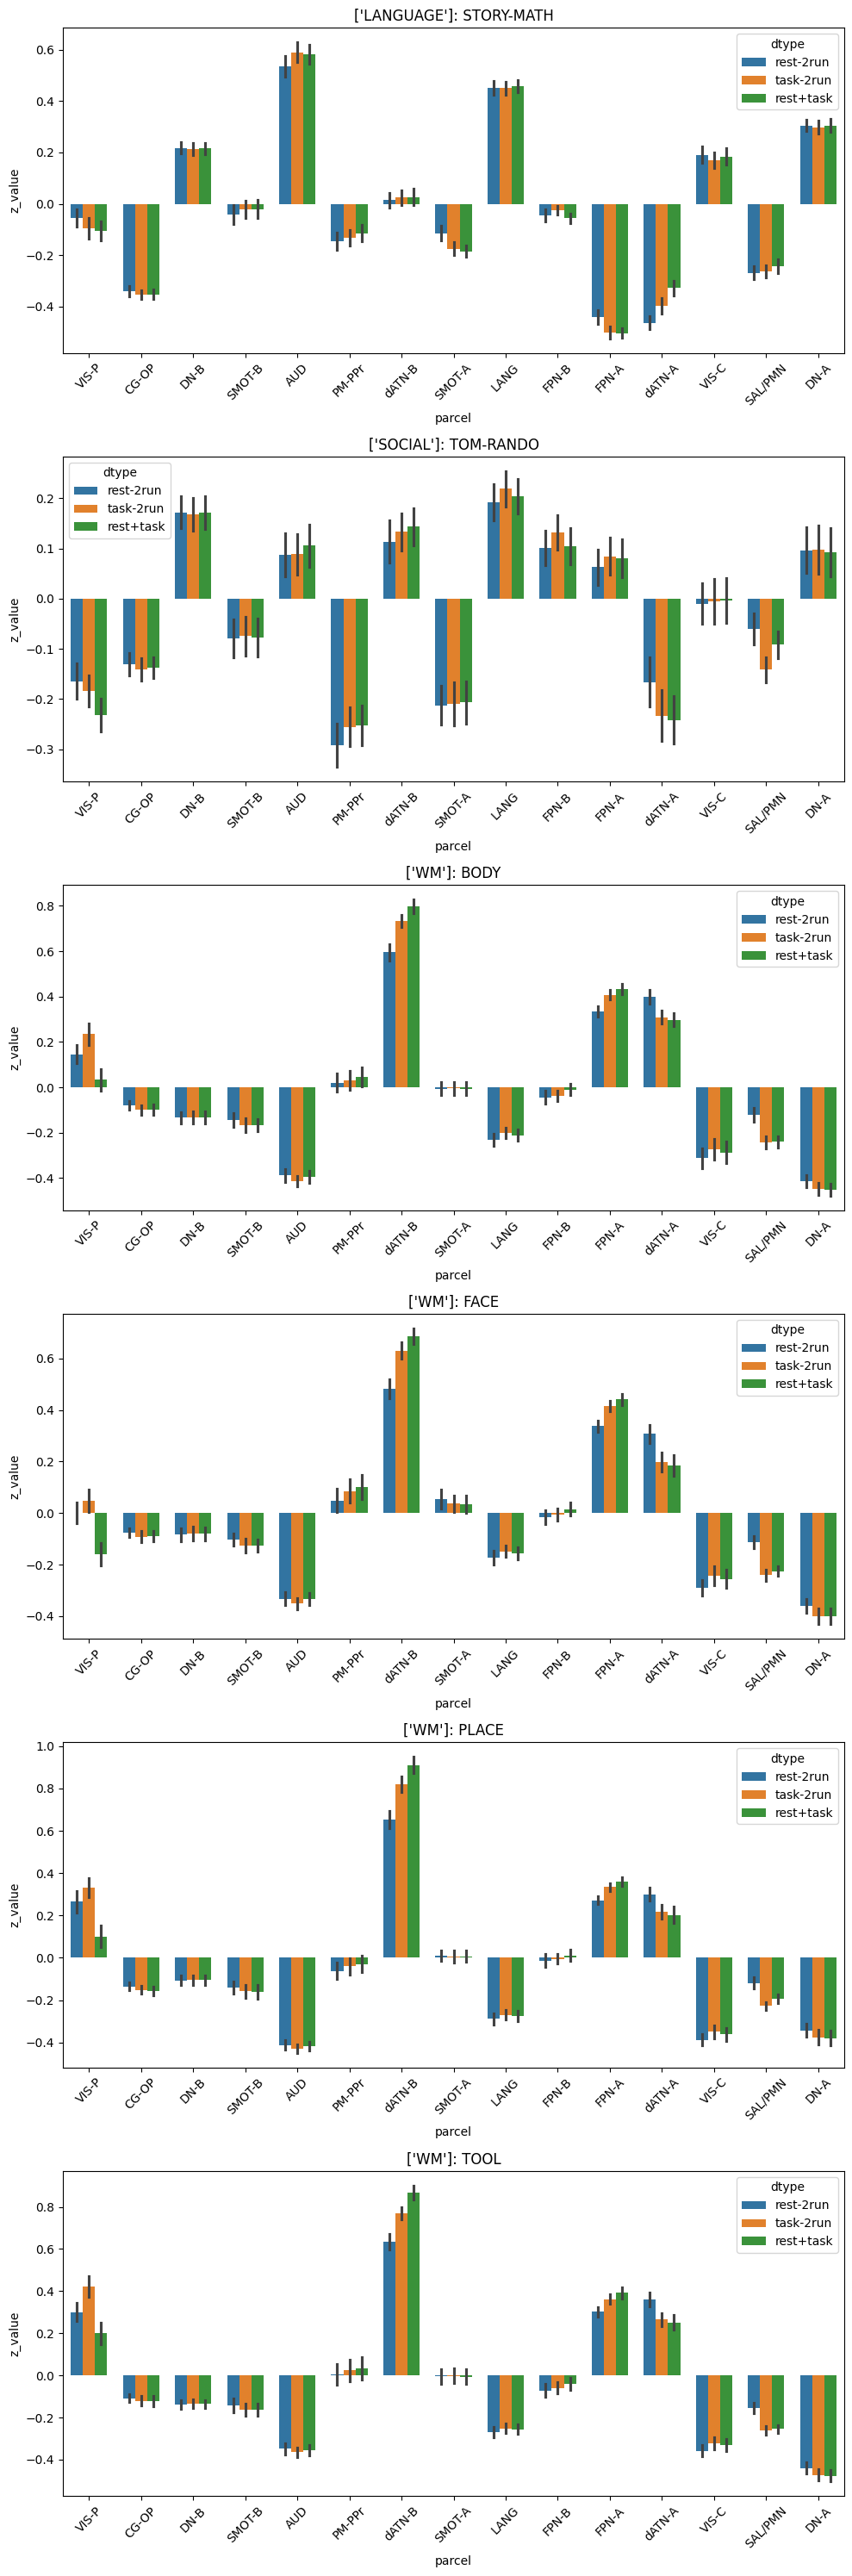

In [33]:
d_type = ['rest-2run', 'task-2run', 'rest+task']
res1 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/HCP203_test_set/zvalues' +
              '/zvalue_indiv_asym_HCP800+HCPrest-2run-indiv_K-15_strengh-2_spatial-5.npy')

res2 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/HCP203_test_set/zvalues' +
              '/zvalue_indiv_asym_HCP800+HCPtask-2run-indiv_K-15_strengh-2_spatial-1.npy')

res3 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/HCP203_test_set/zvalues' +
              '/zvalue_indiv_asym_HCP800+HCPrest+task-indiv_K-15_strengh-1_spatial-1.npy')

DU15, net_name, colors = gp.get_DU15_parcellation(file_name='DU15NET_Prior', atlas_space='fs32k')
df_all = pd.DataFrame()
for j, res in enumerate([res1,res2,res3]):
    for i in [9,39,46,47,48,49]:
        df = plot_zvalues(res, i, t_info, parcel_name=net_name[1:])
        df['dtype'] = d_type[j]
        df_all = pd.concat([df_all, df], ignore_index=True)

df_all['contrast_name']=[s.rstrip('_hp200_s2_MSMAll') for s in df_all.contrast_name]

con_nam = df_all['contrast_name'].unique()

plt.figure(figsize=(10, 5 * len(con_nam)))

for n, c_name in enumerate(con_nam):
    this_df_all = df_all.loc[df_all['contrast_name']==c_name]
    domain = this_df_all['domain'].unique()
    
    plt.subplot(len(con_nam),1,n+1)
    sb.barplot(data=this_df_all, x='parcel', y='z_value', hue='dtype', errorbar='se', width=0.7)
    plt.xticks(rotation=45)
    plt.title(f'{domain}: {c_name}')


plt.tight_layout()
plt.show()

# K=15, RANDY15 Resting prior + individual resting-state data

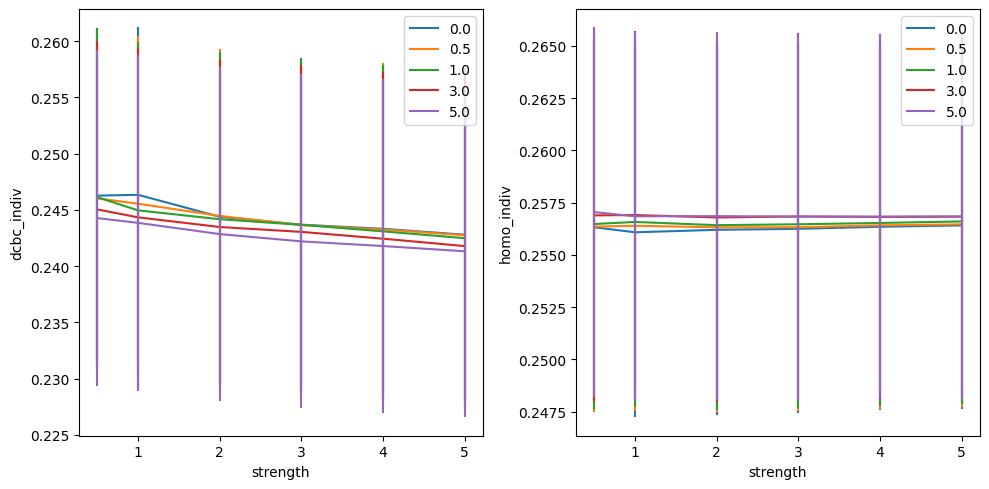

In [3]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP40+RANDYrest-5run_indiv_k-15_test_on_RANDYrest_Tseries.tsv', sep='\t')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,2,2)
sb.lineplot(data=results, x="strength", y='homo_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

## Z values

In [7]:
import sys
sys.path.append('/PHShome/dz010/Workspace/IndividualParcellation/scripts')

from IndividualParcellation.scripts.indiv_eval_hcp import *
HCP_DIR = '/data/tge/Tian/HCP_img'

align, net_name, colors = get_kong2019_17_parcellation()
DU15, net_name, colors = gp.get_DU15_parcellation(file_name='DU15NET_Prior', atlas_space='fs32k')

t_data, t_info = load_randy_contrasts(ses_id='all', subj=None, hemis='L', smooth=2)
pd.set_option('display.max_rows', None)
t_info['task_name'] = t_info['domain']
t_info

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


,sn,cond_id,contrast_name,domain,task_name
0,sub-02,1,PASTFUTUREmPRESENT,Episodic_Projection,Episodic_Projection
1,sub-02,2,GLUTESmALL,Motor,Motor
2,sub-02,3,RFOOTmLFOOT,Motor,Motor
3,sub-02,4,RHANDmLHAND,Motor,Motor
4,sub-02,5,TONGUEmALL,Motor,Motor
5,sub-02,6,2BACKm0BACK_ALL,N-Back,N-Back
6,sub-02,7,2BACKm0BACK_FACE,N-Back,N-Back
7,sub-02,8,2BACKm0BACK_LETTER,N-Back,N-Back
8,sub-02,9,2BACKm0BACK_RHYME,N-Back,N-Back
9,sub-02,10,2BACKm0BACK_SCENE,N-Back,N-Back


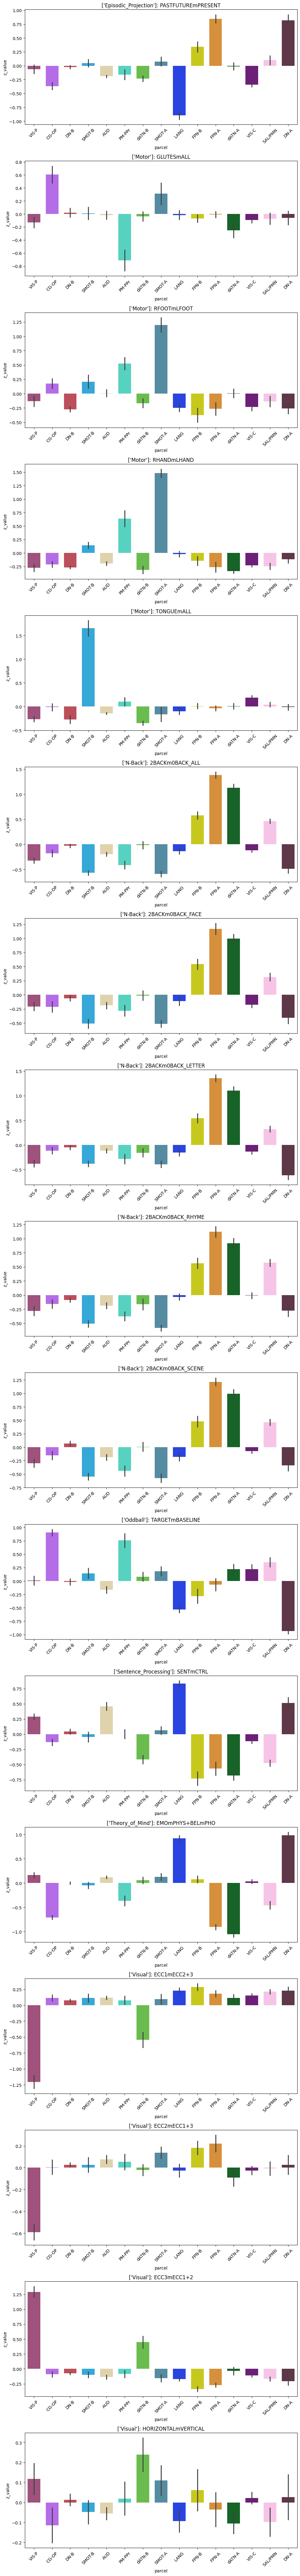

In [10]:
d_type = ['rest-2run', 'task-2run', 'rest+task']
color_list = [tuple(color) for color in colors[1:,:]]

res = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
              '/zvalue_indiv_asym_HCP40+RANDYrest-5run-indiv_K-15_strengh-1_spatial-0.npy')

df_all = pd.DataFrame()
for i in range(17):
    df = plot_zvalues(res, i, t_info, parcel_name=net_name[1:])
    df_all = pd.concat([df_all, df], ignore_index=True)

con_nam = df_all['contrast_name'].unique()
plt.figure(figsize=(10, 5 * len(con_nam)))

for n, c_name in enumerate(con_nam):
    this_df_all = df_all.loc[df_all['contrast_name']==c_name]
    domain = this_df_all['domain'].unique()
    
    plt.subplot(len(con_nam),1,n+1)
    sb.barplot(data=this_df_all, x='parcel', y='z_value', errorbar='se', palette=color_list, width=0.7)
    plt.xticks(rotation=45)
    plt.title(f'{domain}: {c_name}')


plt.tight_layout()
plt.show()